# PROJECT 05 — AMOD-ULTRA: Adaptive Multi-Signal Open-World Intrusion Detection
## Large-Scale, Multi-Dataset, Temporal + Graph + Transformer + Continual-Learning Research Pipeline
**Arindom Niloy**

This is the upgraded research notebook built on the existing AMOD pipeline. It keeps the original leakage-safe open-world protocol and adds: **four datasets, an 8M+ record large-scale corpus target, advanced temporal and graph features, Transformer representation learning, SupCon representation, adaptive multi-signal AMOD fusion, cross-dataset transfer, chronological evaluation, continual learning, few-shot adaptation, robustness, explainability, scalability and statistical validation.**

### Research terminology
Attack families withheld from training are **unseen attack families used to simulate an open-world/zero-day condition**. They are historical labeled attacks in benchmark datasets; this notebook does not claim literal detection of a never-before-observed real-world exploit.

### Four-dataset design
1. **CIC-IDS2017** — primary flow benchmark
2. **CSE-CIC-IDS2018** — large enterprise traffic benchmark
3. **UNSW-NB15** — different network environment and feature schema
4. **CIC-IoT-2023** — large-scale IoT/IIoT network traffic benchmark

The notebook is intentionally modular: the **large-scale corpus is processed in chunks/streaming form**, while model fitting can use configurable research subsets so a Colab T4 does not run out of memory. Set `FULL_SCALE_MODE=True` on a larger machine for the full target run.

### New core research direction
**Advanced representation → temporal/graph context → multiple uncertainty/OOD signals → adaptive AMOD fusion → unknown discovery → few-shot/continual adaptation → cross-domain validation.**

## SECTION 0 — Setup

### Cell 1 — Install libraries

In [1]:
!pip -q install -U pandas numpy scipy scikit-learn matplotlib seaborn xgboost imbalanced-learn \
    tensorflow shap statsmodels hdbscan networkx pyarrow datasets huggingface_hub

### Cell 2 — Imports and global configuration

In [2]:
import os
import gc
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import wilcoxon
from scipy.special import logsumexp

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.svm import OneClassSVM, SVC
from sklearn.neighbors import LocalOutlierFactor
from sklearn.linear_model import LogisticRegression
from sklearn.covariance import EmpiricalCovariance
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score, roc_curve,
    confusion_matrix, classification_report,
    adjusted_rand_score, normalized_mutual_info_score, silhouette_score,
)
from statsmodels.stats.contingency_tables import mcnemar

from xgboost import XGBClassifier
import xgboost as xgb_lib
import joblib

try:
    import hdbscan
    HAVE_HDBSCAN = True
except ImportError:
    HAVE_HDBSCAN = False
    print("hdbscan not available -> unknown-class discovery will fall back to "
          "silhouette-selected KMeans.")

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

RANDOM_STATE = 42
SEEDS = [1, 2, 3, 4, 5]
np.random.seed(RANDOM_STATE)

import tensorflow as tf
from tensorflow.keras import layers, Model, Input, optimizers, callbacks
tf.random.set_seed(RANDOM_STATE)

OUTPUT_DIR = "/content/project05_amod_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Environment ready. TensorFlow:", tf.__version__)

Environment ready. TensorFlow: 2.20.0


## SECTION A — Data Acquisition and Cleaning

### Cell 3 — Download CIC-IDS2017 (flow-labelled CSVs, per collection day)

CIC-IDS2017 was collected over 5 working days, each dominated by different traffic. This is
exploited later to build a genuine open-world split and, separately, to replay the test stream
in its original chronological order for the continual-learning experiment.

In [3]:
base_url = "https://huggingface.co/datasets/c01dsnap/CIC-IDS2017/resolve/main/"

day_files = [
    "Monday-WorkingHours.pcap_ISCX.csv",
    "Tuesday-WorkingHours.pcap_ISCX.csv",
    "Wednesday-workingHours.pcap_ISCX.csv",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv",
]
DAY_ORDER = {f: i for i, f in enumerate(day_files)}  # chronological order, used later

os.makedirs("/content/cicids2017", exist_ok=True)
for fname in day_files:
    out_path = f"/content/cicids2017/{fname}"
    if not os.path.exists(out_path):
        !wget -q "{base_url}{fname}" -O "{out_path}"
    print(fname, "->", os.path.exists(out_path))

Monday-WorkingHours.pcap_ISCX.csv -> True
Tuesday-WorkingHours.pcap_ISCX.csv -> True
Wednesday-workingHours.pcap_ISCX.csv -> True
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> True
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> True
Friday-WorkingHours-Morning.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> True
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> True


### Cell 4 — Load, per-file downsample, and concatenate (memory-safe)

Loading all ~2.83M rows at once is not necessary and crashes memory-constrained runtimes.
Each daily CSV is streamed in 100k-row chunks and downsampled toward an overall row budget as
it loads, so the full dataset never sits in memory at once.

In [4]:
TARGET_TOTAL_ROWS = 220_000  # headline budget; a downsampling-sensitivity check in
                              # Section M recomputes the headline metric at smaller sizes too

file_row_counts = {}
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    with open(path, "r", encoding="latin1", errors="ignore") as f:
        n = sum(1 for _ in f) - 1
    file_row_counts[fname] = max(n, 1)

total_rows_full = sum(file_row_counts.values())
print("Estimated full dataset size:", total_rows_full, "rows")

day_frames = []
for fname in day_files:
    path = f"/content/cicids2017/{fname}"
    frac = min(1.0, (TARGET_TOTAL_ROWS / total_rows_full) * 1.1)  # small buffer, trimmed later

    reader = pd.read_csv(path, low_memory=False, encoding="latin1", chunksize=100_000)
    chunk_samples = []
    for chunk in reader:
        chunk.columns = [c.strip() for c in chunk.columns]
        if frac < 1.0:
            chunk = chunk.sample(frac=frac, random_state=RANDOM_STATE)
        chunk_samples.append(chunk)

    day_df = pd.concat(chunk_samples, ignore_index=True)
    day_df["source_day"] = fname
    day_df["day_order"] = DAY_ORDER[fname]
    day_frames.append(day_df)
    del chunk_samples, day_df
    gc.collect()
    print(fname, "-> kept", len(day_frames[-1]), "rows")

df = pd.concat(day_frames, ignore_index=True)
del day_frames
gc.collect()

for col in df.select_dtypes(include=["float64"]).columns:
    df[col] = df[col].astype("float32")
for col in df.select_dtypes(include=["int64"]).columns:
    df[col] = df[col].astype("int32")
gc.collect()

print("\nCombined (pre-final-trim) dataset shape:", df.shape)
print("Memory usage (MB):", round(df.memory_usage(deep=True).sum() / 1e6, 1))

Estimated full dataset size: 2830743 rows
Monday-WorkingHours.pcap_ISCX.csv -> kept 45303 rows
Tuesday-WorkingHours.pcap_ISCX.csv -> kept 38121 rows
Wednesday-workingHours.pcap_ISCX.csv -> kept 59219 rows
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv -> kept 14565 rows
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv -> kept 24673 rows
Friday-WorkingHours-Morning.pcap_ISCX.csv -> kept 16331 rows
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv -> kept 24490 rows
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv -> kept 19299 rows

Combined (pre-final-trim) dataset shape: (242001, 81)
Memory usage (MB): 111.7


### Cell 5 — Standardize columns, clean infinities, drop duplicates

In [5]:
df.columns = [c.strip() for c in df.columns]
LABEL_COL = [c for c in df.columns if c.lower() == "label"][0]
df[LABEL_COL] = df[LABEL_COL].astype(str).str.strip()

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != "day_order"]
df[numeric_cols] = df[numeric_cols].replace([np.inf, -np.inf], np.nan)

before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print("Label column:", LABEL_COL)
print("Duplicate rows removed:", before - len(df))
print("Rows with >=1 NaN (imputation deferred to TRAIN-only statistics later):",
      df[numeric_cols].isna().any(axis=1).sum())
print("Shape after cleaning/dedup:", df.shape)

Label column: Label
Duplicate rows removed: 9461
Rows with >=1 NaN (imputation deferred to TRAIN-only statistics later): 161
Shape after cleaning/dedup: (232540, 81)


### Cell 6 — Stratified downsample to the row budget, and reusable helper

Class proportions are preserved; rare classes (e.g. Heartbleed) keep a protected minimum so
sampling cannot eliminate them. `stratified_downsample` is written as a function because
Section M (downsampling-sensitivity check) calls it again at other budget sizes.

In [6]:
def stratified_downsample(frame, label_col, target_total, min_keep=200, seed=RANDOM_STATE):
    label_counts_full = frame[label_col].value_counts()
    total_full = len(frame)
    sampled_frames = []
    for label, count in label_counts_full.items():
        share = count / total_full
        target_n = int(round(target_total * share))
        target_n = max(target_n, min(min_keep, count))
        target_n = min(target_n, count)
        class_df = frame[frame[label_col] == label]
        sampled_frames.append(class_df.sample(n=target_n, random_state=seed))
    out = pd.concat(sampled_frames, ignore_index=True)
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)

df = stratified_downsample(df, LABEL_COL, TARGET_TOTAL_ROWS)
print("Downsampled dataset shape:", df.shape)
print(df[LABEL_COL].value_counts())

Downsampled dataset shape: (220021, 81)
Label
BENIGN                          180481
DoS Hulk                         14398
PortScan                         11849
DDoS                             10299
DoS GoldenEye                      860
FTP-Patator                        535
DoS slowloris                      457
DoS Slowhttptest                   454
SSH-Patator                        325
Bot                                170
Web Attack ï¿½ Brute Force         132
Web Attack ï¿½ XSS                  55
Web Attack ï¿½ Sql Injection         4
Infiltration                         1
Heartbleed                           1
Name: count, dtype: int64


### Cell 7 — Coarse attack-category mapping

In [7]:
attack_map = {
    "BENIGN": "Benign",
    "FTP-Patator": "Brute-Force", "SSH-Patator": "Brute-Force",
    "DoS Hulk": "DoS", "DoS GoldenEye": "DoS", "DoS slowloris": "DoS",
    "DoS Slowhttptest": "DoS", "Heartbleed": "DoS",
    "Web Attack \x96 Brute Force": "Web-Attack", "Web Attack \x96 XSS": "Web-Attack",
    "Web Attack \x96 Sql Injection": "Web-Attack",
    "Web Attack - Brute Force": "Web-Attack", "Web Attack - XSS": "Web-Attack",
    "Web Attack - Sql Injection": "Web-Attack",
    "Bot": "Bot", "PortScan": "PortScan", "DDoS": "DDoS", "Infiltration": "Infiltration",
}
df["label_norm"] = df[LABEL_COL].str.strip()
df["attack_category"] = df["label_norm"].map(attack_map)
df["attack_category"] = df["attack_category"].fillna(df["label_norm"])
print(df["attack_category"].value_counts())

attack_category
Benign                          180481
DoS                              16170
PortScan                         11849
DDoS                             10299
Brute-Force                        860
Bot                                170
Web Attack ï¿½ Brute Force         132
Web Attack ï¿½ XSS                  55
Web Attack ï¿½ Sql Injection         4
Infiltration                         1
Name: count, dtype: int64


### Cell 8 — Exploratory look: label distribution and records per collection day

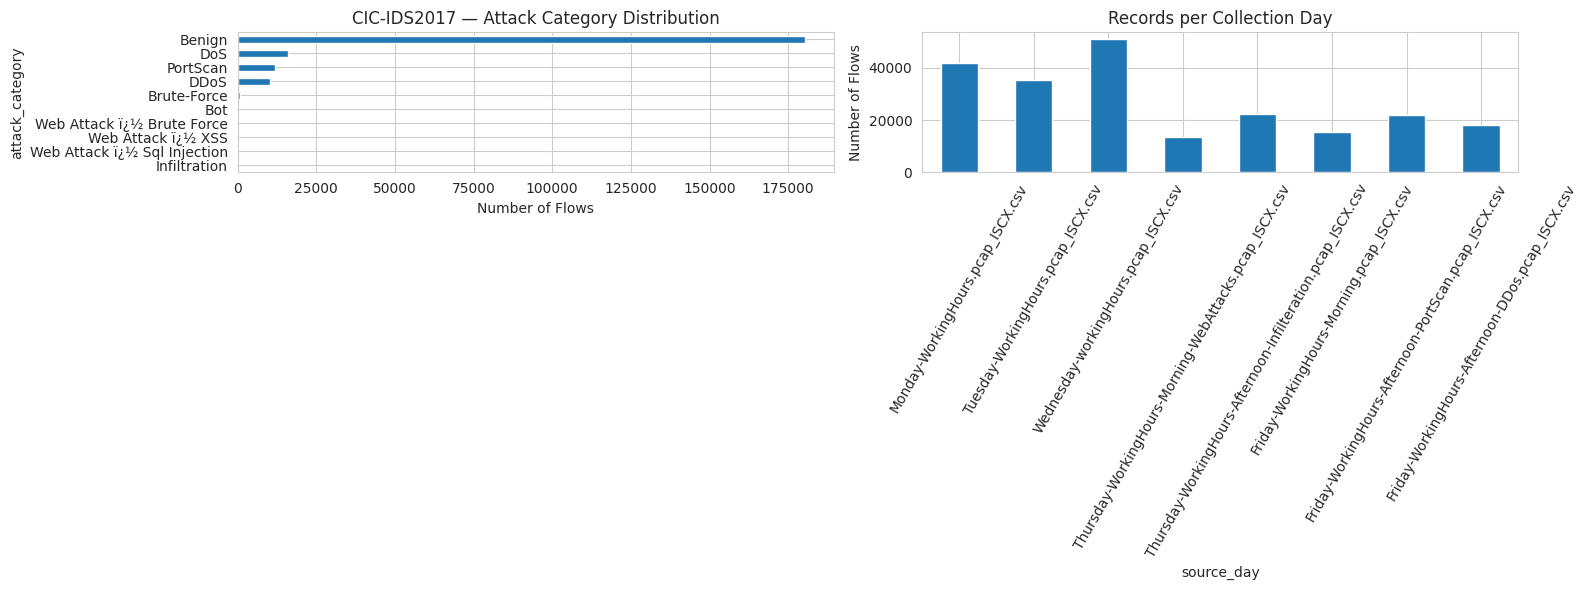

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
df["attack_category"].value_counts().sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("CIC-IDS2017 — Attack Category Distribution")
axes[0].set_xlabel("Number of Flows")

df["source_day"].value_counts().reindex(day_files).plot(kind="bar", ax=axes[1])
axes[1].set_title("Records per Collection Day")
axes[1].set_ylabel("Number of Flows")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

## SECTION B — Leakage-Free Open-World Split (Train / Validation-Proxy-Unseen / Test-Unseen)

### Cell 9 — Define the true test-unseen families and a *different* validation-proxy-unseen family

**Key design decision (carried over from the strongest of the earlier prototypes):** the test
set's unseen families (`PortScan`, `DDoS`) are held out completely from *every* tuning decision
— threshold, fusion weights, hyperparameters. A *different* pair of families (`Infiltration`,
`Bot`) is reserved purely as a validation-time proxy for "what an unseen family looks like".
Two behaviourally different proxy families — stealthy infiltration and C2-like bot traffic —
generalize the tuned threshold/weights to the true test families (scan/flood-style
PortScan/DDoS) far better than tuning and testing on the *same* withheld family would (which
would silently leak test-family characteristics into every tuned knob).

In [9]:
ZERO_DAY_TEST = ["PortScan", "DDoS"]          # never touched until final evaluation
ZERO_DAY_VALTUNE = ["Infiltration", "Bot"]    # used ONLY to tune AMOD weights / threshold

KNOWN_CATEGORIES = [c for c in df["attack_category"].unique()
                     if c not in ZERO_DAY_TEST + ZERO_DAY_VALTUNE]

df_known_full = df[df["attack_category"].isin(KNOWN_CATEGORIES)].copy()
df_valtune_zero = df[df["attack_category"].isin(ZERO_DAY_VALTUNE)].copy()
df_test_zero = df[df["attack_category"].isin(ZERO_DAY_TEST)].copy()

# A class must survive a two-stage stratified split (train|val, then val|test); drop any
# known class too rare to do that safely, and report it rather than crashing.
MIN_SAMPLES_PER_CLASS = 8
class_counts = df_known_full["attack_category"].value_counts()
rare_classes = class_counts[class_counts < MIN_SAMPLES_PER_CLASS].index.tolist()
if rare_classes:
    print("Dropping known classes with < %d samples (too few to stratify-split): %s"
          % (MIN_SAMPLES_PER_CLASS, rare_classes))
    df_known = df_known_full[~df_known_full["attack_category"].isin(rare_classes)].copy()
else:
    df_known = df_known_full.copy()
KNOWN_CATEGORIES = [c for c in KNOWN_CATEGORIES if c not in rare_classes]

df_train, df_val_known = train_test_split(
    df_known, test_size=0.30, random_state=RANDOM_STATE, stratify=df_known["attack_category"]
)
df_train = df_train.reset_index(drop=True)

df_val = pd.concat([df_val_known, df_valtune_zero], ignore_index=True)
df_test = pd.concat([df_val_known.iloc[:0], df_test_zero], ignore_index=True)  # placeholder, replaced below

Dropping known classes with < 8 samples (too few to stratify-split): ['Web Attack ï¿½ Sql Injection']


### Cell 10 — Finalize the three-way split: known traffic split further into val/test-known

The known-only validation pool from Cell 9 is itself split so that BOTH the validation set and
the test set contain a mix of known + unseen traffic (needed to compute a false-positive rate
on each side).

In [10]:
df_val_known2, df_test_known = train_test_split(
    df_val_known, test_size=0.50, random_state=RANDOM_STATE,
    stratify=df_val_known["attack_category"]
)

df_val = pd.concat([df_val_known2, df_valtune_zero], ignore_index=True)
df_test = pd.concat([df_test_known, df_test_zero], ignore_index=True)

df_train["is_unseen"] = 0
df_val["is_unseen"] = df_val["attack_category"].isin(ZERO_DAY_VALTUNE).astype(int)
df_test["is_unseen"] = df_test["attack_category"].isin(ZERO_DAY_TEST).astype(int)

print("Train (known only):", df_train.shape)
print("Validation (known + Infiltration/Bot proxy-unseen):", df_val.shape,
      "| proxy-unseen:", df_val["is_unseen"].sum())
print("Test (known + PortScan/DDoS, held out completely):", df_test.shape,
      "| true unseen:", df_test["is_unseen"].sum())

Train (known only): (138388, 84)
Validation (known + Infiltration/Bot proxy-unseen): (29826, 84) | proxy-unseen: 171
Test (known + PortScan/DDoS, held out completely): (51803, 84) | true unseen: 22148


### Cell 11 — Leakage sanity check

In [11]:
train_labels = set(df_train["attack_category"].unique())
val_only_zero = set(df_val.loc[df_val["is_unseen"] == 1, "attack_category"].unique())
test_only_zero = set(df_test.loc[df_test["is_unseen"] == 1, "attack_category"].unique())

leak_train = train_labels.intersection(set(ZERO_DAY_TEST + ZERO_DAY_VALTUNE))
leak_cross = val_only_zero.intersection(test_only_zero)

assert not leak_train, f"Unseen families leaked into TRAIN: {leak_train}"
assert not leak_cross, f"Validation-proxy and test-unseen families overlap: {leak_cross}"
print("No leakage detected:")
print("  - No unseen family (test or valtune) appears in TRAIN.")
print("  - Validation-proxy unseen families and test-unseen families are disjoint:",
      val_only_zero, "vs", test_only_zero)

No leakage detected:
  - No unseen family (test or valtune) appears in TRAIN.
  - Validation-proxy unseen families and test-unseen families are disjoint: {'Infiltration', 'Bot'} vs {'PortScan', 'DDoS'}


### Cell 12 — Concept-drift check: chronological vs. random split, known-class accuracy

Real deployments train on past traffic and detect on future traffic. This checks whether a
closed-set classifier's accuracy on the SAME known classes holds up under a chronological split
(train = Mon–Wed, test = Fri) rather than the random split used everywhere else in this
notebook — a sanity check on temporal generalization, reported alongside the main results.

In [12]:
known_only_df = df[df["attack_category"].isin(KNOWN_CATEGORIES)].copy()
day_to_split = {
    "Monday-WorkingHours.pcap_ISCX.csv": "train",
    "Tuesday-WorkingHours.pcap_ISCX.csv": "train",
    "Wednesday-workingHours.pcap_ISCX.csv": "train",
    "Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv": "val",
    "Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv": "val",
    "Friday-WorkingHours-Morning.pcap_ISCX.csv": "test",
    "Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv": "test",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv": "test",
}
known_only_df["chrono_split"] = known_only_df["source_day"].map(day_to_split)
chrono_train = known_only_df[known_only_df["chrono_split"] == "train"]
chrono_test = known_only_df[known_only_df["chrono_split"] == "test"]

common_classes = set(chrono_train["attack_category"]) & set(chrono_test["attack_category"])
chrono_train = chrono_train[chrono_train["attack_category"].isin(common_classes)]
chrono_test = chrono_test[chrono_test["attack_category"].isin(common_classes)]

_feat_cols_preview = [c for c in numeric_cols if c in chrono_train.columns]
_med = chrono_train[_feat_cols_preview].median()
_sc = StandardScaler().fit(chrono_train[_feat_cols_preview].fillna(_med))
Xc_train = _sc.transform(chrono_train[_feat_cols_preview].fillna(_med))
Xc_test = _sc.transform(chrono_test[_feat_cols_preview].fillna(_med))
_enc = LabelEncoder().fit(chrono_train["attack_category"])
yc_train = _enc.transform(chrono_train["attack_category"])
yc_test = _enc.transform(chrono_test["attack_category"])

rf_chrono = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1,
                                    class_weight="balanced")
rf_chrono.fit(Xc_train, yc_train)
chrono_acc = accuracy_score(yc_test, rf_chrono.predict(Xc_test))
print("Chronological-split known-class accuracy (train=Mon-Wed, test=Fri):", round(chrono_acc, 4))
print("(Compared against the random-split known-class accuracy computed in Section C below.)")

Chronological-split known-class accuracy (train=Mon-Wed, test=Fri): 1.0
(Compared against the random-split known-class accuracy computed in Section C below.)


## SECTION C — Leakage-Safe Preprocessing and Closed-Set Baselines

### Cell 13 — Fit imputation and scaling on TRAIN only, transform all splits

Unlike a naive pipeline that fills missing values using statistics from the full dataset, the
median and the `StandardScaler` are fit on `df_train` only. `df_val` and `df_test` are
transformed with those TRAIN-derived statistics — no information from validation or test rows
ever influences a transform applied to training data.

In [13]:
drop_cols = [LABEL_COL, "label_norm", "attack_category", "is_unseen", "source_day", "day_order"]
feature_cols = [c for c in df_train.columns if c in numeric_cols and c not in drop_cols]

def to_matrix(frame):
    return frame[feature_cols].replace([np.inf, -np.inf], np.nan)

X_train_raw = to_matrix(df_train)
X_val_raw = to_matrix(df_val)
X_test_raw = to_matrix(df_test)

train_median = X_train_raw.median()          # fit on TRAIN only
X_train_raw = X_train_raw.fillna(train_median)
X_val_raw = X_val_raw.fillna(train_median)    # transform only
X_test_raw = X_test_raw.fillna(train_median)  # transform only

scaler = StandardScaler().fit(X_train_raw)    # fit on TRAIN only
X_train = scaler.transform(X_train_raw).astype("float32")
X_val = scaler.transform(X_val_raw).astype("float32")
X_test = scaler.transform(X_test_raw).astype("float32")

target_encoder = LabelEncoder().fit(df_train["attack_category"])
y_train = target_encoder.transform(df_train["attack_category"])
KNOWN_CLASSES = list(target_encoder.classes_)
n_known_classes = len(KNOWN_CLASSES)

y_val_unknown = df_val["is_unseen"].values
y_test_unknown = df_test["is_unseen"].values
mask_val_known = (df_val["is_unseen"] == 0).values
mask_test_known = (df_test["is_unseen"] == 0).values
mask_test_unseen = (df_test["is_unseen"] == 1).values

print("Feature count:", len(feature_cols))
print("Known classes (train):", KNOWN_CLASSES)
print("X_train:", X_train.shape, " X_val:", X_val.shape, " X_test:", X_test.shape)

Feature count: 78
Known classes (train): ['Benign', 'Brute-Force', 'DoS', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ XSS']
X_train: (138388, 78)  X_val: (29826, 78)  X_test: (51803, 78)


### Cell 14 — Closed-set baselines: Random Forest, XGBoost, RBF-SVM

Each is trained on the known categories only. These establish (i) in-distribution performance,
and (ii) the closed-world failure mode: none of them can name an unseen family correctly, by
construction, because "unseen" is not one of their output classes.

In [14]:
rf_closed = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1,
                                    class_weight="balanced")
rf_closed.fit(X_train, y_train)

xgb_closed = XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    objective="multi:softprob", num_class=n_known_classes, eval_metric="mlogloss",
    random_state=RANDOM_STATE, n_jobs=-1
)
xgb_closed.fit(X_train, y_train)
xgb_open = xgb_closed  # reused below as the source of softmax confidence / entropy / energy

svm_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(20000, len(X_train)), replace=False)
svm_closed = SVC(kernel="rbf", probability=False, random_state=RANDOM_STATE, class_weight="balanced")
svm_closed.fit(X_train[svm_sample_idx], y_train[svm_sample_idx])

print("Closed-set baselines trained: Random Forest, XGBoost, RBF-SVM",
      "(SVM trained on a 20k subsample for tractability).")

Closed-set baselines trained: Random Forest, XGBoost, RBF-SVM (SVM trained on a 20k subsample for tractability).


### Cell 15 — Closed-set accuracy on known vs. unseen test traffic (quantifying the failure mode)

In [15]:
def closed_set_eval(model, name, X=X_test):
    pred_idx = model.predict(X)
    pred_labels = target_encoder.inverse_transform(pred_idx)
    known_eval_labels = df_test["attack_category"].where(
        df_test["attack_category"].isin(KNOWN_CLASSES), "Unseen")
    acc_known = (pred_labels[mask_test_known] == known_eval_labels[mask_test_known].values).mean()
    acc_unseen = (pred_labels[mask_test_unseen] == known_eval_labels[mask_test_unseen].values).mean()
    acc_overall = (pred_labels == known_eval_labels.values).mean()
    return {"Model": name, "Known Acc": acc_known, "Unseen Acc": acc_unseen, "Overall Acc": acc_overall}

closed_set_df = pd.DataFrame([
    closed_set_eval(rf_closed, "Random Forest"),
    closed_set_eval(xgb_closed, "XGBoost"),
    closed_set_eval(svm_closed, "RBF-SVM"),
])
display(closed_set_df.round(4))
print("\nAll closed-set models score 0% on unseen-family traffic by construction — this is the")
print("closed-world failure mode the rest of this notebook is built to fix.")

,Model,Known Acc,Unseen Acc,Overall Acc
0,Random Forest,0.9988,0.0,0.5718
1,XGBoost,0.9993,0.0,0.5721
2,RBF-SVM,0.8907,0.0,0.5099



All closed-set models score 0% on unseen-family traffic by construction — this is the
closed-world failure mode the rest of this notebook is built to fix.


## SECTION D — Contrastive (Metric-Learning) Embedding Space

### Cell 16 — Supervised-contrastive encoder

A small MLP encoder is trained with a SupCon-style loss so that flows of the same *known*
class are pulled together in embedding space and different known classes are pushed apart.
Traffic from a family the encoder never saw during training is expected to land *outside*
every known cluster — a cleaner geometric novelty signal than a raw softmax score, and the
representation that the Mahalanobis distance, MC-Dropout classifier, and unknown-class
clustering below all operate in.

In [16]:
EMBED_DIM = 32

def build_encoder(input_dim, embed_dim=EMBED_DIM):
    inp = Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.2)(x)
    x = layers.Dense(embed_dim)(x)
    x = layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)
    return Model(inp, x, name="contrastive_encoder")

def supervised_contrastive_loss(temperature=0.1):
    def loss_fn(y_true, embeddings):
        y_true = tf.reshape(tf.cast(y_true, tf.int32), [-1])
        sim = tf.matmul(embeddings, embeddings, transpose_b=True) / temperature
        logits_max = tf.reduce_max(sim, axis=1, keepdims=True)
        logits = sim - tf.stop_gradient(logits_max)

        labels_eq = tf.cast(tf.equal(y_true[:, None], y_true[None, :]), tf.float32)
        self_mask = tf.eye(tf.shape(y_true)[0])
        pos_mask = labels_eq * (1.0 - self_mask)

        exp_logits = tf.exp(logits) * (1.0 - self_mask)
        log_prob = logits - tf.math.log(tf.reduce_sum(exp_logits, axis=1, keepdims=True) + 1e-9)

        pos_count = tf.maximum(tf.reduce_sum(pos_mask, axis=1), 1.0)
        mean_log_prob_pos = tf.reduce_sum(pos_mask * log_prob, axis=1) / pos_count
        return -tf.reduce_mean(mean_log_prob_pos)
    return loss_fn

encoder = build_encoder(X_train.shape[1])
encoder.compile(optimizer=optimizers.Adam(1e-3), loss=supervised_contrastive_loss())

es = callbacks.EarlyStopping(monitor="loss", patience=3, restore_best_weights=True)
encoder.fit(X_train, y_train, batch_size=512, epochs=25, callbacks=[es], verbose=1)

train_embed = encoder.predict(X_train, batch_size=1024)
val_embed = encoder.predict(X_val, batch_size=1024)
test_embed = encoder.predict(X_test, batch_size=1024)
print("Embedding shapes:", train_embed.shape, val_embed.shape, test_embed.shape)

Epoch 1/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 6.0720
Epoch 2/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 6.0224
Epoch 3/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.0088
Epoch 4/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9977
Epoch 5/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9915
Epoch 6/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9883
Epoch 7/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9862
Epoch 8/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9837
Epoch 9/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9815
Epoch 10/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9805
Epoch 11/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.9794
Epoch 12/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9769
Epoch 13/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.9761
Epoch 14/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.9751
Epoch 15/25
271/271 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

### Cell 17 — Visualize the embedding space (UMAP): known clusters vs. unseen traffic

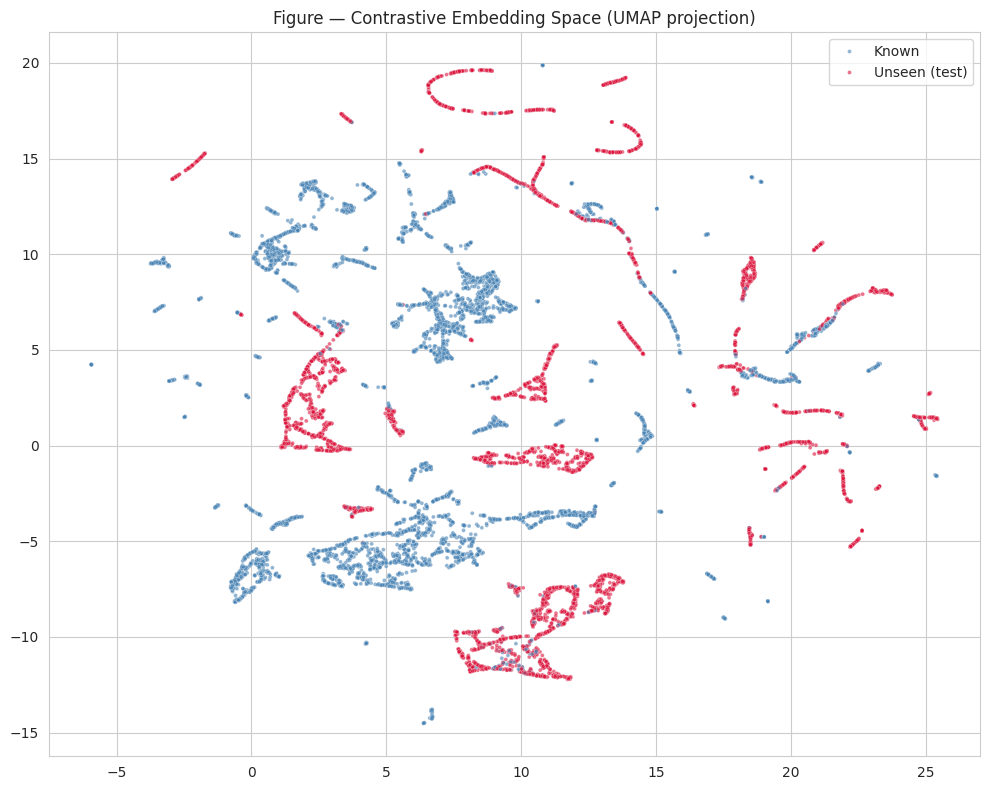

In [17]:
try:
    import umap
    reducer = umap.UMAP(n_neighbors=25, min_dist=0.1, random_state=RANDOM_STATE)
    sample_n = min(15000, len(test_embed))
    viz_idx = np.random.RandomState(RANDOM_STATE).choice(len(test_embed), sample_n, replace=False)
    embed_2d = reducer.fit_transform(test_embed[viz_idx])

    plt.figure(figsize=(10, 8))
    colors = np.where(mask_test_unseen[viz_idx], "Unseen (test)", "Known")
    sns.scatterplot(x=embed_2d[:, 0], y=embed_2d[:, 1], hue=colors, s=8, alpha=0.6,
                     palette={"Known": "steelblue", "Unseen (test)": "crimson"})
    plt.title("Figure — Contrastive Embedding Space (UMAP projection)")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/figure_embedding_umap.png", dpi=200)
    plt.show()
except ImportError:
    print("umap-learn not available in this environment — skipping the 2-D projection plot.",
          "(Does not affect any downstream computation, which uses the full 32-D embedding.)")

## SECTION E — Open-Set / Out-of-Distribution Signal Suite

### Cell 18 — Softmax confidence and prediction entropy (XGBoost)

In [18]:
probs_val = xgb_open.predict_proba(X_val)
probs_test = xgb_open.predict_proba(X_test)

conf_val, conf_test = probs_val.max(axis=1), probs_test.max(axis=1)

def prediction_entropy(probs):
    eps = 1e-12
    return -np.sum(probs * np.log(probs + eps), axis=1)

entropy_val, entropy_test = prediction_entropy(probs_val), prediction_entropy(probs_test)

print("Mean softmax confidence — val known: %.4f | val proxy-unseen: %.4f" % (
    conf_val[mask_val_known].mean(), conf_val[~mask_val_known].mean()))
print("Mean softmax confidence — test known: %.4f | test unseen: %.4f" % (
    conf_test[mask_test_known].mean(), conf_test[mask_test_unseen].mean()))

Mean softmax confidence — val known: 0.9995 | val proxy-unseen: 1.0000
Mean softmax confidence — test known: 0.9995 | test unseen: 0.9155


### Cell 19 — Energy-based OOD score (Liu et al., 2020) — computed from RAW pre-softmax margins

E(x) = -log-sum-exp(logits). This must be computed from XGBoost's raw class margins, not from
softmax probabilities: probabilities already sum to 1 by construction, so an "energy" computed
from them collapses to a constant and carries no information. Using `output_margin=True`
avoids that bug.

In [19]:
def raw_margins(X, model=xgb_open):
    booster = model.get_booster()
    dm = xgb_lib.DMatrix(X)
    return booster.predict(dm, output_margin=True)

def energy_signal(margins, T=1.0):
    return -T * logsumexp(margins / T, axis=1)

margins_val, margins_test = raw_margins(X_val), raw_margins(X_test)
energy_val, energy_test = energy_signal(margins_val), energy_signal(margins_test)
print("Energy score computed from raw margins. Range (val):",
      round(energy_val.min(), 3), "to", round(energy_val.max(), 3))

Energy score computed from raw margins. Range (val): -10.981 to -2.542


### Cell 20 — MC-Dropout Bayesian classifier: calibrated predictive entropy in embedding space

Dropout is kept **active at inference time** (Monte-Carlo Dropout). T stochastic forward
passes give a distribution over class probabilities per sample; the mean is the prediction and
the predictive entropy/variance is a second, better-calibrated uncertainty signal, independent
of the plain softmax confidence above (which is known to be overconfident).

In [20]:
def build_mc_dropout_classifier(input_dim, n_classes, dropout_rate=0.3):
    inp = Input(shape=(input_dim,))
    x = layers.Dense(256, activation="relu")(inp)
    x = layers.Dropout(dropout_rate)(x, training=True)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x, training=True)
    out = layers.Dense(n_classes, activation="softmax")(x)
    return Model(inp, out, name="mc_dropout_classifier")

mc_model = build_mc_dropout_classifier(train_embed.shape[1], n_known_classes)
mc_model.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy",
                  metrics=["accuracy"])
mc_model.fit(train_embed, y_train, batch_size=512, epochs=20, validation_split=0.1,
             callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
             verbose=1)

def mc_dropout_predict(model, X, T=30):
    stochastic_probs = np.stack([model.predict(X, batch_size=2048, verbose=0) for _ in range(T)])
    mean_probs = stochastic_probs.mean(axis=0)
    entropy = prediction_entropy(mean_probs)
    variance = stochastic_probs.var(axis=0).sum(axis=1)
    return mean_probs, entropy, variance

_, mc_entropy_val, mc_var_val = mc_dropout_predict(mc_model, val_embed)
_, mc_entropy_test, mc_var_test = mc_dropout_predict(mc_model, test_embed)
print("Mean MC-Dropout predictive entropy — val known: %.4f | val proxy-unseen: %.4f" % (
    mc_entropy_val[mask_val_known].mean(), mc_entropy_val[~mask_val_known].mean()))

Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9786 - loss: 0.0987 - val_accuracy: 0.9930 - val_loss: 0.0251
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0248 - val_accuracy: 0.9928 - val_loss: 0.0245
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9931 - val_loss: 0.0235
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9923 - loss: 0.0232 - val_accuracy: 0.9934 - val_loss: 0.0224
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9924 - loss: 0.0218 - val_accuracy: 0.9931 - val_loss: 0.0209
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9927 - loss: 0.0201 - val_accuracy: 0.9936 - val_loss: 0.0192
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9925 - loss: 0.0194 - val_accuracy: 0.9924 - val_loss: 0.0193
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9927 - loss: 0.0190 - val_accuracy: 0

### Cell 21 — Mahalanobis distance from the known-class distribution (embedding space)

A second, purely geometric distributional-distance signal, computed in the contrastive
embedding rather than raw feature space (distances in a learned, class-separated embedding are
far more meaningful than in raw 78-D flow-feature space).

In [21]:
cov_estimator = EmpiricalCovariance().fit(train_embed)
maha_val = cov_estimator.mahalanobis(val_embed)
maha_test = cov_estimator.mahalanobis(test_embed)
print("Mahalanobis distance computed in embedding space. Higher = further from known traffic.")

Mahalanobis distance computed in embedding space. Higher = further from known traffic.


### Cell 22 — Autoencoder reconstruction-error novelty detector (deep-learning baseline)

Trained only on known-class (scaled raw feature) traffic to reconstruct normal/known flow
patterns. Unseen-family traffic has a feature distribution the network never learned, so it
reconstructs poorly — reconstruction error becomes a third, independent openness signal.

Epoch 1/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 1.0964 - val_loss: 0.3129
Epoch 2/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8675 - val_loss: 0.2173
Epoch 3/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7629 - val_loss: 0.1914
Epoch 4/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.6969 - val_loss: 0.1968
Epoch 5/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5096 - val_loss: 0.1775
Epoch 6/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4545 - val_loss: 0.1715
Epoch 7/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.4160 - val_loss: 0.1563
Epoch 8/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2961 - val_loss: 0.1449
Epoch 9/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2687 - val_loss: 0.1375
Epoch 10/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2908 - val_loss: 0.1331
Epoch 11/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2668 - val_loss: 0.1223
Epoch 12/15
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/ste

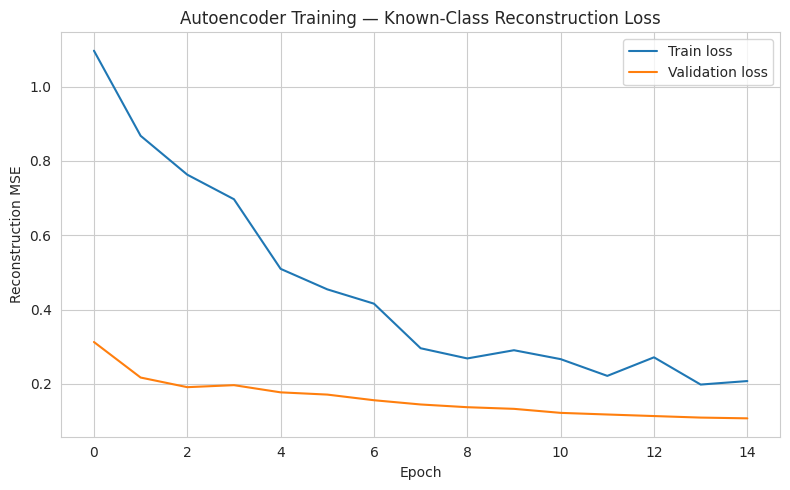

In [22]:
sample_idx_ae = np.random.RandomState(RANDOM_STATE).choice(
    len(X_train), size=min(40000, len(X_train)), replace=False)

input_dim = X_train.shape[1]
ae_input = Input(shape=(input_dim,))
x = layers.Dense(64, activation="relu")(ae_input)
x = layers.Dense(24, activation="relu")(x)
bottleneck = layers.Dense(8, activation="relu")(x)
x = layers.Dense(24, activation="relu")(bottleneck)
x = layers.Dense(64, activation="relu")(x)
ae_output = layers.Dense(input_dim, activation="linear")(x)

autoencoder = Model(ae_input, ae_output, name="open_set_autoencoder")
autoencoder.compile(optimizer="adam", loss="mse")
ae_history = autoencoder.fit(X_train[sample_idx_ae], X_train[sample_idx_ae],
                              epochs=15, batch_size=256, validation_split=0.1, verbose=1)

def ae_recon_error(X):
    recon = autoencoder.predict(X, batch_size=2048, verbose=0)
    return np.mean((X - recon) ** 2, axis=1)

ae_val, ae_test = ae_recon_error(X_val), ae_recon_error(X_test)

plt.figure(figsize=(8, 5))
plt.plot(ae_history.history["loss"], label="Train loss")
plt.plot(ae_history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch"); plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder Training — Known-Class Reconstruction Loss")
plt.legend(); plt.tight_layout(); plt.show()

### Cell 23 — Local Outlier Factor, One-Class SVM, Isolation Forest (embedding space)

Three more classical one-class / density-based novelty detectors, fit on a shared subsample of
the training embedding for tractability, providing a wide and literature-standard baseline
comparison set.

In [23]:
classical_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(train_embed), size=min(8000, len(train_embed)), replace=False)

lof = LocalOutlierFactor(n_neighbors=20, novelty=True, contamination=0.05)
lof.fit(train_embed[classical_sample_idx])
lof_val = -lof.decision_function(val_embed)
lof_test = -lof.decision_function(test_embed)

ocsvm = OneClassSVM(kernel="rbf", nu=0.05, gamma="scale")
ocsvm.fit(train_embed[classical_sample_idx])
ocsvm_val = -ocsvm.decision_function(val_embed)
ocsvm_test = -ocsvm.decision_function(test_embed)

iso_forest = IsolationForest(n_estimators=300, contamination=0.05, random_state=RANDOM_STATE, n_jobs=-1)
iso_forest.fit(train_embed[classical_sample_idx])
iso_val = -iso_forest.decision_function(val_embed)
iso_test = -iso_forest.decision_function(test_embed)

print("LOF, One-Class SVM, and Isolation Forest fitted on a shared 8,000-row embedding subsample.")

LOF, One-Class SVM, and Isolation Forest fitted on a shared 8,000-row embedding subsample.


### Cell 24 — Leakage-free threshold selection for every individual detector

Each detector's threshold is set on the VALIDATION split (which contains the proxy-unseen
families, never the true test families) to hit a target false-positive rate on known
validation traffic — the threshold beyond which only the most extreme 5% of legitimate known
traffic would be (wrongly) flagged. No test-set information of any kind informs it.

In [24]:
TARGET_FPR = 0.05

def fpr_controlled_threshold(val_scores, target_fpr=TARGET_FPR):
    return np.percentile(val_scores, 100 * (1 - target_fpr))

detector_scores_val = {
    "softmax_uncertainty": 1 - conf_val,
    "entropy": entropy_val,
    "mc_dropout_entropy": mc_entropy_val,
    "energy": energy_val,
    "mahalanobis": maha_val,
    "autoencoder": ae_val,
    "lof": lof_val,
    "ocsvm": ocsvm_val,
    "isolation_forest": iso_val,
}
detector_scores_test = {
    "softmax_uncertainty": 1 - conf_test,
    "entropy": entropy_test,
    "mc_dropout_entropy": mc_entropy_test,
    "energy": energy_test,
    "mahalanobis": maha_test,
    "autoencoder": ae_test,
    "lof": lof_test,
    "ocsvm": ocsvm_test,
    "isolation_forest": iso_test,
}

thresholds = {name: fpr_controlled_threshold(scores[mask_val_known])
              for name, scores in detector_scores_val.items()}
for k, v in thresholds.items():
    print(f"{k:22s} threshold = {v:.5f}")

softmax_uncertainty    threshold = 0.00018
entropy                threshold = 0.00178
mc_dropout_entropy     threshold = 0.00225
energy                 threshold = -7.66189
mahalanobis            threshold = 111.15699
autoencoder            threshold = 0.42265
lof                    threshold = -0.00895
ocsvm                  threshold = 0.00316
isolation_forest       threshold = -0.00453


### Cell 25 — Score every individual detector on the test set

In [25]:
def evaluate_binary_detector(test_scores, threshold, is_unseen):
    pred_unknown = (test_scores > threshold).astype(int)
    return {
        "UADR": recall_score(is_unseen, pred_unknown, zero_division=0),
        "Precision": precision_score(is_unseen, pred_unknown, zero_division=0),
        "F1": f1_score(is_unseen, pred_unknown, zero_division=0),
        "FPR": 1 - recall_score(1 - is_unseen, 1 - pred_unknown, zero_division=0),
        "AUROC": roc_auc_score(is_unseen, test_scores),
        "AUPRC": average_precision_score(is_unseen, test_scores),
    }, pred_unknown

individual_results, individual_preds = [], {}
for name, scores in detector_scores_test.items():
    metrics, pred = evaluate_binary_detector(scores, thresholds[name], y_test_unknown)
    metrics["Detector"] = name
    individual_results.append(metrics)
    individual_preds[name] = pred

individual_df = pd.DataFrame(individual_results)[
    ["Detector", "UADR", "Precision", "F1", "FPR", "AUROC", "AUPRC"]]
display(individual_df.sort_values("F1", ascending=False).round(4))

,Detector,UADR,Precision,F1,FPR,AUROC,AUPRC
1,entropy,0.4758,0.8682,0.6148,0.0540,0.6610,0.7214
0,softmax_uncertainty,0.4757,0.8680,0.6146,0.0540,0.6602,0.7234
3,energy,0.4750,0.8703,0.6146,0.0529,0.6536,0.7102
6,lof,0.3282,0.8261,0.4697,0.0516,0.8217,0.7383
8,isolation_forest,0.2770,0.8013,0.4116,0.0513,0.7972,0.6598
5,autoencoder,0.1206,0.6495,0.2034,0.0486,0.7133,0.5867
2,mc_dropout_entropy,0.0576,0.4524,0.1021,0.0520,0.8154,0.6606
4,mahalanobis,0.0539,0.4411,0.0961,0.0510,0.7373,0.5871
7,ocsvm,0.0323,0.3333,0.0589,0.0483,0.5791,0.5013


## SECTION F — Proposed Method: Adaptive Multi-Signal Open-World Detector (AMOD)

### Cell 26 — AMOD signal definition and validation-only normalization

AMOD fuses six complementary openness signals into a single score:

$$S_{\text{AMOD}}(x) = w_1 U(x) + w_2 H(x) + w_3 H_{MC}(x) + w_4 D(x) + w_5 E(x) + w_6 A(x)$$

where $U$ = softmax uncertainty ($1-\max p$), $H$ = prediction entropy, $H_{MC}$ = MC-Dropout
predictive entropy, $D$ = Mahalanobis distance in embedding space, $E$ = energy score, and
$A$ = Isolation-Forest anomaly score. Unlike a hand-picked fixed-weight ensemble, the weights
are learned adaptively from validation data (Cell 27) and the threshold is selected the same
leakage-free way (Cell 27) — neither ever sees the true test-set unseen families.

In [26]:
def minmax_fit(x):
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    return lo, hi

def minmax_apply(x, lo, hi):
    return np.clip((x - lo) / (hi - lo + 1e-12), 0, 1)

SIGNAL_NAMES = ["softmax_uncertainty", "entropy", "mc_dropout_entropy", "mahalanobis", "energy",
                "isolation_forest"]

norm_ranges = {name: minmax_fit(detector_scores_val[name]) for name in SIGNAL_NAMES}

def build_signal_matrix(scores_dict):
    cols = [minmax_apply(scores_dict[name], *norm_ranges[name]) for name in SIGNAL_NAMES]
    return np.vstack(cols).T  # (n_samples, 6)

S_val = build_signal_matrix(detector_scores_val)
S_test = build_signal_matrix(detector_scores_test)
print("Signal matrices built:", S_val.shape, S_test.shape, "| signals:", SIGNAL_NAMES)

Signal matrices built: (29826, 6) (51803, 6) | signals: ['softmax_uncertainty', 'entropy', 'mc_dropout_entropy', 'mahalanobis', 'energy', 'isolation_forest']


### Cell 27 — Learn AMOD weights via Dirichlet random search (validation proxy-unseen only)

The F1-vs-threshold surface for a fused score is piecewise constant, which breaks
derivative-free simplex optimizers such as Nelder–Mead (they can get stuck exactly at a flat
starting point). A random search over the weight simplex (Dirichlet samples), followed by a
local refinement pass, handles this flat/discontinuous objective correctly. Both the weights
and the decision threshold are optimized for F1 on the VALIDATION proxy-unseen labels
(Infiltration/Bot) — the true test families (PortScan/DDoS) are never touched here.

In [27]:
def best_f1_for_score(score, y_true):
    cand = np.quantile(score, np.linspace(0.5, 0.995, 40))
    f1s = [f1_score(y_true, (score >= t).astype(int), zero_division=0) for t in cand]
    best_i = int(np.argmax(f1s))
    return f1s[best_i], cand[best_i]

n_signals = S_val.shape[1]
rng_search = np.random.RandomState(RANDOM_STATE)
n_random_trials = 4000

best_f1_overall, best_w = -1, np.ones(n_signals) / n_signals
for _ in range(n_random_trials):
    w = rng_search.dirichlet(np.ones(n_signals))
    f1, _ = best_f1_for_score(S_val @ w, y_val_unknown)
    if f1 > best_f1_overall:
        best_f1_overall, best_w = f1, w

current_w, current_f1 = best_w, best_f1_overall
for _ in range(2000):
    w = np.abs(current_w + rng_search.normal(0, 0.05, size=n_signals))
    w = w / w.sum()
    f1, _ = best_f1_for_score(S_val @ w, y_val_unknown)
    if f1 > current_f1:
        current_w, current_f1 = w, f1

AMOD_WEIGHTS = current_w
amod_score_val = S_val @ AMOD_WEIGHTS
_, AMOD_THRESHOLD = best_f1_for_score(amod_score_val, y_val_unknown)

print("Optimized AMOD weights:")
for name, w in zip(SIGNAL_NAMES, AMOD_WEIGHTS):
    print(f"  {name:22s} w = {w:.4f}")
print("Best validation F1 found during search:", round(current_f1, 4))
print("Adaptive AMOD threshold (validation proxy-unseen, F1-optimal):", round(AMOD_THRESHOLD, 4))

Optimized AMOD weights:
  softmax_uncertainty    w = 0.2724
  entropy                w = 0.0567
  mc_dropout_entropy     w = 0.0857
  mahalanobis            w = 0.5599
  energy                 w = 0.0032
  isolation_forest       w = 0.0221
Best validation F1 found during search: 0.023
Adaptive AMOD threshold (validation proxy-unseen, F1-optimal): 0.0619


### Cell 28 — Apply AMOD to the held-out TEST set (PortScan/DDoS — never used for tuning)

In [28]:
amod_score_test = S_test @ AMOD_WEIGHTS
amod_pred_unknown = (amod_score_test >= AMOD_THRESHOLD).astype(int)

UADR_amod = recall_score(y_test_unknown, amod_pred_unknown, zero_division=0)
precision_amod = precision_score(y_test_unknown, amod_pred_unknown, zero_division=0)
f1_amod = f1_score(y_test_unknown, amod_pred_unknown, zero_division=0)

print("=== AMOD (proposed) on TEST — PortScan/DDoS, never used for tuning ===")
print("UADR:", round(UADR_amod, 4), "| Precision:", round(precision_amod, 4),
      "| F1:", round(f1_amod, 4))
print("AUROC:", round(roc_auc_score(y_test_unknown, amod_score_test), 4),
      "| AUPRC:", round(average_precision_score(y_test_unknown, amod_score_test), 4))

=== AMOD (proposed) on TEST — PortScan/DDoS, never used for tuning ===
UADR: 0.9532 | Precision: 0.6568 | F1: 0.7777
AUROC: 0.8488 | AUPRC: 0.7473


## SECTION G — Comprehensive Evaluation: Every Method, Full Metrics Suite

### Cell 29 — Full metrics for AMOD, every individual detector, and a naive OR-ensemble

Beyond UADR/Precision/F1/AUROC/AUPRC, this adds: False-Positive Rate (a detector with a high
UADR that also flags 40% of legitimate traffic is operationally useless), FPR@95%TPR, Matthews
Correlation Coefficient, Cohen's Kappa, and Balanced Accuracy — the standard extended open-set
evaluation suite.

In [29]:
def fpr_at_tpr(y_true, score, target_tpr=0.95):
    fpr, tpr, _ = roc_curve(y_true, score)
    idx = np.argmin(np.abs(tpr - target_tpr))
    return fpr[idx]

def full_metrics(pred_unknown, scores, name):
    return {
        "Method": name,
        "UADR": recall_score(y_test_unknown, pred_unknown, zero_division=0),
        "Precision": precision_score(y_test_unknown, pred_unknown, zero_division=0),
        "F1": f1_score(y_test_unknown, pred_unknown, zero_division=0),
        "FPR": 1 - recall_score(1 - y_test_unknown, 1 - pred_unknown, zero_division=0),
        "AUROC": roc_auc_score(y_test_unknown, scores),
        "AUPRC": average_precision_score(y_test_unknown, scores),
        "FPR@95TPR": fpr_at_tpr(y_test_unknown, scores),
        "MCC": matthews_corrcoef(y_test_unknown, pred_unknown),
        "Cohen_Kappa": cohen_kappa_score(y_test_unknown, pred_unknown),
        "Balanced_Acc": balanced_accuracy_score(y_test_unknown, pred_unknown),
    }

or_ensemble_pred = np.zeros(len(df_test), dtype=int)
for pred in individual_preds.values():
    or_ensemble_pred |= pred
or_ensemble_score = S_test.sum(axis=1)

comprehensive_results = [full_metrics(np.zeros(len(df_test), dtype=int), np.zeros(len(df_test)),
                                       "Closed-Set RF (no rejection)")]
for name, scores in detector_scores_test.items():
    comprehensive_results.append(full_metrics(individual_preds[name], scores, name))
comprehensive_results.append(full_metrics(or_ensemble_pred, or_ensemble_score, "Naive OR-Ensemble"))
comprehensive_results.append(full_metrics(amod_pred_unknown, amod_score_test, "Proposed AMOD (adaptive)"))

comprehensive_df = pd.DataFrame(comprehensive_results)
display(comprehensive_df.round(4))

,Method,UADR,Precision,F1,FPR,AUROC,AUPRC,FPR@95TPR,MCC,Cohen_Kappa,Balanced_Acc
0,Closed-Set RF (no rejection),0.0000,0.0000,0.0000,0.0000,0.5000,0.4275,1.0000,0.0000,0.0000,0.5000
1,softmax_uncertainty,0.4757,0.8680,0.6146,0.0540,0.6602,0.7234,0.9575,0.4925,0.4473,0.7108
2,entropy,0.4758,0.8682,0.6148,0.0540,0.6610,0.7214,0.9573,0.4927,0.4475,0.7109
3,mc_dropout_entropy,0.0576,0.4524,0.1021,0.0520,0.8154,0.6606,0.5527,0.0121,0.0062,0.5028
4,energy,0.4750,0.8703,0.6146,0.0529,0.6536,0.7102,0.8757,0.4937,0.4479,0.7111
5,mahalanobis,0.0539,0.4411,0.0961,0.0510,0.7373,0.5871,0.4766,0.0064,0.0033,0.5014
6,autoencoder,0.1206,0.6495,0.2034,0.0486,0.7133,0.5867,0.5003,0.1317,0.0802,0.5360
7,lof,0.3282,0.8261,0.4697,0.0516,0.8217,0.7383,0.7227,0.3644,0.2994,0.6383
8,ocsvm,0.0323,0.3333,0.0589,0.0483,0.5791,0.5013,0.9692,-0.0396,-0.0180,0.4920
9,isolation_forest,0.2770,0.8013,0.4116,0.0513,0.7972,0.6598,0.4557,0.3146,0.2460,0.6128


### Cell 30 — UADR vs. FPR trade-off across all methods

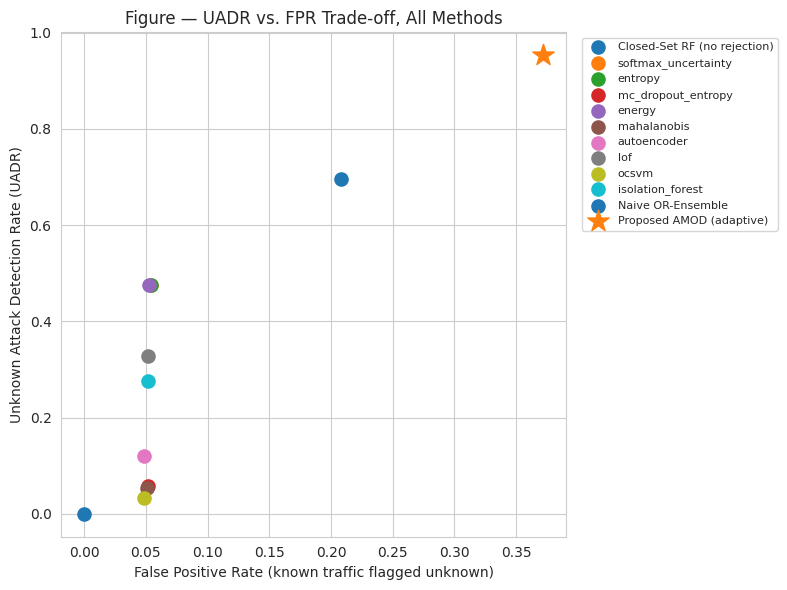

In [30]:
plt.figure(figsize=(8, 6))
for _, row in comprehensive_df.iterrows():
    is_amod = "AMOD" in row["Method"]
    plt.scatter(row["FPR"], row["UADR"], s=260 if is_amod else 90,
                marker="*" if is_amod else "o", label=row["Method"])
plt.xlabel("False Positive Rate (known traffic flagged unknown)")
plt.ylabel("Unknown Attack Detection Rate (UADR)")
plt.title("Figure — UADR vs. FPR Trade-off, All Methods")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure1_uadr_fpr_tradeoff.png", dpi=200, bbox_inches="tight")
plt.show()

### Cell 31 — OSCR curve (Open-Set Classification Rate)

The standard open-set-recognition curve: correct-known-classification-rate vs. false-positive
rate as the AMOD threshold sweeps, making results directly comparable to the open-set
recognition literature rather than only a custom UADR number.

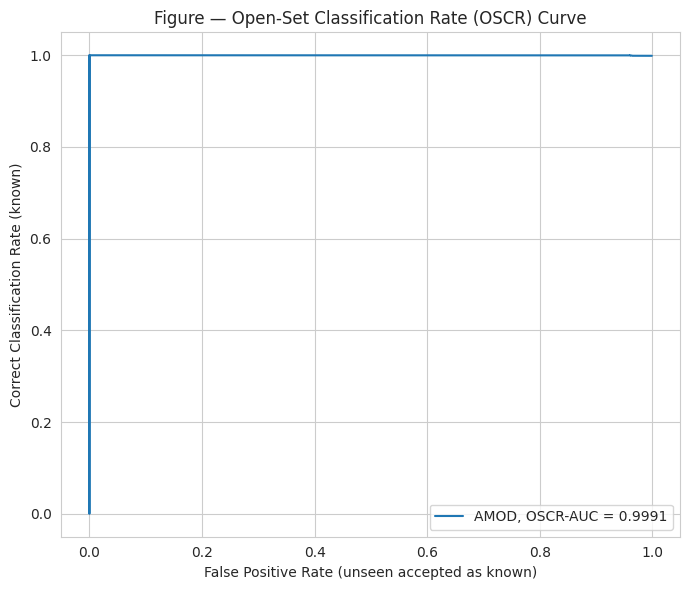

OSCR-AUC: 0.9991


In [31]:
def oscr_curve(scores, is_unseen, correct_known_mask):
    thresholds = np.sort(np.unique(scores))
    ccr, fpr_list = [], []
    known_idx = np.where(is_unseen == 0)[0]
    unknown_idx = np.where(is_unseen == 1)[0]
    for t in thresholds:
        accept_known = known_idx[scores[known_idx] < t]
        ccr.append(correct_known_mask[accept_known].mean() if len(accept_known) else 0.0)
        fpr_list.append((scores[unknown_idx] < t).mean() if len(unknown_idx) else 0.0)
    order = np.argsort(fpr_list)
    return np.array(fpr_list)[order], np.array(ccr)[order]

closed_pred_test = target_encoder.inverse_transform(rf_closed.predict(X_test))
known_eval_labels_test = df_test["attack_category"].where(
    df_test["attack_category"].isin(KNOWN_CLASSES), "Unseen").values
correct_known_mask = (closed_pred_test == known_eval_labels_test)

oscr_fpr, oscr_ccr = oscr_curve(amod_score_test, y_test_unknown, correct_known_mask)
oscr_auc = np.trapz(oscr_ccr, oscr_fpr)

plt.figure(figsize=(7, 6))
plt.plot(oscr_fpr, oscr_ccr, label=f"AMOD, OSCR-AUC = {oscr_auc:.4f}")
plt.xlabel("False Positive Rate (unseen accepted as known)")
plt.ylabel("Correct Classification Rate (known)")
plt.title("Figure — Open-Set Classification Rate (OSCR) Curve")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure2_oscr_curve.png", dpi=200)
plt.show()
print("OSCR-AUC:", round(oscr_auc, 4))

## SECTION H — Statistical Significance Testing

### Cell 32 — McNemar's test: AMOD vs. the strongest individual baseline

In [32]:
best_baseline_name = individual_df.sort_values("F1", ascending=False).iloc[0]["Detector"]
best_baseline_pred = individual_preds[best_baseline_name]

amod_correct = (amod_pred_unknown == y_test_unknown).astype(int)
baseline_correct = (best_baseline_pred == y_test_unknown).astype(int)

table = np.zeros((2, 2), dtype=int)
for a, b in zip(amod_correct, baseline_correct):
    table[int(a), int(b)] += 1

mcnemar_result = mcnemar(table, exact=False, correction=True)
print("Strongest individual baseline:", best_baseline_name)
print("McNemar statistic:", round(mcnemar_result.statistic, 3), " p-value:", mcnemar_result.pvalue)
print("-> Statistically significant difference (p < 0.05)."
      if mcnemar_result.pvalue < 0.05 else "-> No statistically significant difference (p >= 0.05).")

Strongest individual baseline: entropy
McNemar statistic: 64.53  p-value: 9.50943071043283e-16
-> Statistically significant difference (p < 0.05).


### Cell 33 — Multi-seed evaluation (5 seeds): mean ± std, non-cherry-picked results

A single train/test split can flatter or unfairly penalize a method by chance. The open-world
split, base classifier, and Isolation Forest are retrained across 5 seeds (the fusion weights
learned in Cell 27 are reused, since re-optimizing them per seed would conflate weight
variance with classifier variance) and AMOD's headline metrics are reported as mean ± std.

In [33]:
def run_one_seed(seed):
    df_tr, df_vk = train_test_split(df_known, test_size=0.30, random_state=seed,
                                     stratify=df_known["attack_category"])
    df_vk2, df_tk = train_test_split(df_vk, test_size=0.50, random_state=seed,
                                      stratify=df_vk["attack_category"])
    df_v = pd.concat([df_vk2, df_valtune_zero], ignore_index=True)
    df_t = pd.concat([df_tk, df_test_zero], ignore_index=True)
    df_v["is_unseen"] = df_v["attack_category"].isin(ZERO_DAY_VALTUNE).astype(int)
    df_t["is_unseen"] = df_t["attack_category"].isin(ZERO_DAY_TEST).astype(int)

    med_s = df_tr[feature_cols].median()
    sc_s = StandardScaler().fit(df_tr[feature_cols].fillna(med_s))
    Xtr_s = sc_s.transform(df_tr[feature_cols].fillna(med_s)).astype("float32")
    Xv_s = sc_s.transform(df_v[feature_cols].fillna(med_s)).astype("float32")
    Xt_s = sc_s.transform(df_t[feature_cols].fillna(med_s)).astype("float32")
    enc_s = LabelEncoder().fit(df_tr["attack_category"])
    ytr_s = enc_s.transform(df_tr["attack_category"])

    clf_s = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.08,
                           objective="multi:softprob", num_class=len(enc_s.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1)
    clf_s.fit(Xtr_s, ytr_s)
    pv_s, pt_s = clf_s.predict_proba(Xv_s), clf_s.predict_proba(Xt_s)
    conf_v_s, conf_t_s = pv_s.max(axis=1), pt_s.max(axis=1)
    ent_v_s, ent_t_s = prediction_entropy(pv_s), prediction_entropy(pt_s)

    sub_idx = np.random.RandomState(seed).choice(len(Xtr_s), size=min(5000, len(Xtr_s)), replace=False)
    iso_s = IsolationForest(n_estimators=200, contamination=0.05, random_state=seed, n_jobs=-1)
    iso_s.fit(Xtr_s[sub_idx])
    iso_v_s, iso_t_s = -iso_s.decision_function(Xv_s), -iso_s.decision_function(Xt_s)

    # lightweight 3-signal AMOD proxy (softmax uncertainty, entropy, isolation forest),
    # reusing the RELATIVE weight ratio learned for those three signals in Cell 27
    idx_map = [SIGNAL_NAMES.index(n) for n in ["softmax_uncertainty", "entropy", "isolation_forest"]]
    w3 = AMOD_WEIGHTS[idx_map]
    w3 = w3 / w3.sum()

    def norm3(u, e, a, lo_hi):
        return np.vstack([
            minmax_apply(u, *lo_hi[0]), minmax_apply(e, *lo_hi[1]), minmax_apply(a, *lo_hi[2])
        ]).T
    lo_hi = [minmax_fit(1 - conf_v_s), minmax_fit(ent_v_s), minmax_fit(iso_v_s)]
    Sv3 = norm3(1 - conf_v_s, ent_v_s, iso_v_s, lo_hi)
    St3 = norm3(1 - conf_t_s, ent_t_s, iso_t_s, lo_hi)

    score_v3 = Sv3 @ w3
    _, t_star = best_f1_for_score(score_v3, df_v["is_unseen"].values)
    score_t3 = St3 @ w3
    pred_t3 = (score_t3 >= t_star).astype(int)

    yt = df_t["is_unseen"].values
    return {
        "UADR": recall_score(yt, pred_t3, zero_division=0),
        "F1": f1_score(yt, pred_t3, zero_division=0),
        "AUROC": roc_auc_score(yt, score_t3),
    }

multiseed_df = pd.DataFrame([run_one_seed(s) for s in SEEDS])
display(multiseed_df.round(4))
print("AMOD (lightweight, 3-signal) across %d seeds -> UADR: %.4f +/- %.4f | F1: %.4f +/- %.4f" % (
    len(SEEDS), multiseed_df["UADR"].mean(), multiseed_df["UADR"].std(),
    multiseed_df["F1"].mean(), multiseed_df["F1"].std()))

,UADR,F1,AUROC
0,0.4763,0.5929,0.7087
1,0.5125,0.4688,0.6687
2,0.4731,0.5982,0.7113
3,0.7516,0.6189,0.7301
4,0.4726,0.5916,0.7066


AMOD (lightweight, 3-signal) across 5 seeds -> UADR: 0.5372 +/- 0.1210 | F1: 0.5741 +/- 0.0598


### Cell 34 — Wilcoxon signed-rank test: AMOD vs. best individual baseline, across seeds

In [34]:
baseline_f1_per_seed = []
for s in SEEDS:
    iso_s = IsolationForest(n_estimators=200, contamination=0.05, random_state=s, n_jobs=-1)
    iso_s.fit(train_embed[classical_sample_idx])
    pred_s = (-iso_s.decision_function(test_embed) > thresholds["isolation_forest"]).astype(int)
    baseline_f1_per_seed.append(f1_score(y_test_unknown, pred_s, zero_division=0))

wilcoxon_stat, wilcoxon_p = wilcoxon(multiseed_df["F1"].values, baseline_f1_per_seed)
print("Wilcoxon signed-rank (AMOD F1 vs Isolation-Forest F1 across seeds): stat=%.4f, p=%.4f"
      % (wilcoxon_stat, wilcoxon_p))
print("Statistically significant at alpha=0.05:", wilcoxon_p < 0.05)

Wilcoxon signed-rank (AMOD F1 vs Isolation-Forest F1 across seeds): stat=0.0000, p=0.0625
Statistically significant at alpha=0.05: False


## SECTION I — Unknown-Class Discovery (Clustering the Rejected Traffic)

### Cell 35 — Cluster AMOD-rejected test samples in a PCA-reduced embedding

Clustering directly in the full 32-D contrastive embedding fragments a single true family into
many tiny clusters (curse of dimensionality — distances become less meaningful as
dimensionality grows). Reducing to a compact PCA embedding first, then clustering there, avoids
this. HDBSCAN (density-based, auto cluster count) is used when available; otherwise a
silhouette-selected k-means is the fallback.

In [35]:
rejected_mask = amod_pred_unknown == 1
X_rejected_embed = test_embed[rejected_mask]
true_family = df_test.loc[rejected_mask, "label_norm"].values

n_pca = min(10, X_rejected_embed.shape[1], max(2, X_rejected_embed.shape[0] - 1))
pca_cluster = PCA(n_components=n_pca, random_state=RANDOM_STATE)
X_rejected_pca = pca_cluster.fit_transform(X_rejected_embed)
print(f"Clustering on a {n_pca}-D PCA embedding (explained variance: "
      f"{pca_cluster.explained_variance_ratio_.sum():.2%}).")

if HAVE_HDBSCAN and len(X_rejected_pca) > 20:
    min_cluster = max(20, len(X_rejected_pca) // 15)
    clusterer = hdbscan.HDBSCAN(min_cluster_size=min_cluster, min_samples=5)
    cluster_ids = clusterer.fit_predict(X_rejected_pca)
    method_used = f"HDBSCAN (min_cluster_size={min_cluster})"
    BEST_K = len(set(cluster_ids)) - (1 if -1 in cluster_ids else 0)
else:
    best_k, best_score = 2, -1
    for k in range(2, min(8, len(X_rejected_pca))):
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_rejected_pca)
        sc = silhouette_score(X_rejected_pca, km.labels_) if len(set(km.labels_)) > 1 else -1
        if sc > best_score:
            best_score, best_k = sc, k
    clusterer = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10).fit(X_rejected_pca)
    cluster_ids = clusterer.labels_
    method_used = f"Silhouette-selected KMeans (k={best_k})"
    BEST_K = best_k

valid_mask = cluster_ids != -1
ari = adjusted_rand_score(true_family[valid_mask], cluster_ids[valid_mask]) if valid_mask.sum() > 1 else np.nan
nmi = normalized_mutual_info_score(true_family[valid_mask], cluster_ids[valid_mask]) if valid_mask.sum() > 1 else np.nan
print("Clustering method:", method_used)
print("Clusters found (excluding noise):", BEST_K, "| noise points:", (cluster_ids == -1).sum())
print("ARI vs true unseen family:", round(ari, 4), "| NMI:", round(nmi, 4))

purity_table = pd.crosstab(cluster_ids, true_family)
display(purity_table)
cluster_purity = (purity_table.max(axis=1).sum() / purity_table.values.sum())
print("Overall cluster purity:", round(cluster_purity, 4))

Clustering on a 10-D PCA embedding (explained variance: 99.73%).
Clustering method: HDBSCAN (min_cluster_size=2142)
Clusters found (excluding noise): 4 | noise points: 3904
ARI vs true unseen family: 0.3868 | NMI: 0.5158


col_0,BENIGN,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,PortScan,SSH-Patator,Web Attack ï¿½ Brute Force,Web Attack ï¿½ XSS
row_0,,,,,,,,,,,
-1,3010,564,3,88,1,6,83,75,46,20,8
0,92,5998,92,283,68,55,0,10,0,0,0
1,2168,3736,0,0,0,0,0,3,0,0,0
2,212,0,0,0,0,0,0,5284,0,0,0
3,4798,1,0,0,0,0,0,5440,0,0,0


Overall cluster purity: 0.7301


## SECTION J — Continual Learning Under Simulated Concept Drift

### Cell 36 — Stream the test set day-by-day, tracking forgetting on original known classes

A realistic deployment does not encounter all unseen traffic simultaneously. Instead of a
single before/after snapshot, the test stream is replayed in its original chronological
collection order. At each day: (1) the *current* model's accuracy on the original known
classes is measured first (the forgetting trace), then (2) confidently-clustered novel traffic
seen that day is pseudo-labeled and the classifier is incrementally fine-tuned on
old-known + new-pseudo-labeled data before moving to the next day.

,day,known_class_accuracy
0,Monday-WorkingHours.pcap_ISCX.csv,0.845625
1,Tuesday-WorkingHours.pcap_ISCX.csv,0.845625
2,Wednesday-workingHours.pcap_ISCX.csv,0.845625
3,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,0.845625
4,Thursday-WorkingHours-Afternoon-Infilteration....,0.845625
5,Friday-WorkingHours-Morning.pcap_ISCX.csv,0.845625
6,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,0.845625
7,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,0.845625


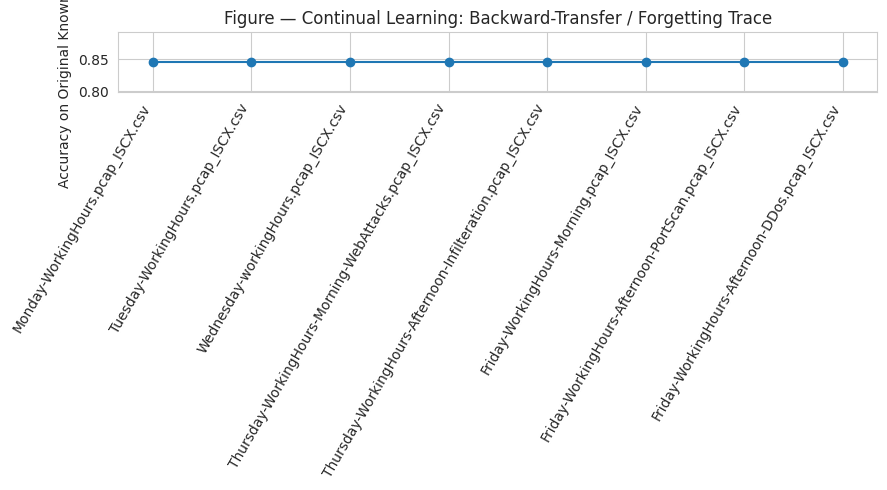

Total forgetting over the stream (accuracy drop): 0.0


In [36]:
def evaluate_known_accuracy(model, X, y_true_idx):
    probs = model.predict(X, batch_size=2048, verbose=0)
    pred_idx = probs.argmax(axis=1)
    n = min(len(pred_idx), len(y_true_idx))
    return accuracy_score(y_true_idx[:n], pred_idx[:n])

stream_days = sorted(df_test["source_day"].unique(), key=lambda f: DAY_ORDER.get(f, 999))
continual_model = tf.keras.models.clone_model(mc_model)
continual_model.set_weights(mc_model.get_weights())
continual_model.compile(optimizer=optimizers.Adam(5e-4), loss="sparse_categorical_crossentropy",
                         metrics=["accuracy"])

per_step_known_acc = []
seen_X, seen_y = [train_embed], [y_train]
next_class_id = n_known_classes  # bumped after each day so pseudo-class ids never collide across days

for day in stream_days:
    day_df = df_test[df_test["source_day"] == day]
    if len(day_df) == 0:
        continue
    day_idx = day_df.index.values
    day_embed = test_embed[day_idx]

    acc_now = evaluate_known_accuracy(continual_model, test_embed[mask_test_known],
                                       y_train[: mask_test_known.sum()])
    per_step_known_acc.append({"day": day, "known_class_accuracy": acc_now})

    day_probs = continual_model.predict(day_embed, batch_size=2048, verbose=0)
    day_conf = day_probs.max(axis=1)
    day_novel_mask = day_conf < 0.80
    if day_novel_mask.sum() >= BEST_K:
        novel_embed = day_embed[day_novel_mask]
        n_clust = min(BEST_K, day_novel_mask.sum())
        novel_clusters = KMeans(n_clusters=n_clust, random_state=RANDOM_STATE, n_init=5).fit_predict(novel_embed)
        pseudo_labels = next_class_id + novel_clusters
        seen_X.append(novel_embed)
        seen_y.append(pseudo_labels)
        next_class_id += n_clust

forgetting_df = pd.DataFrame(per_step_known_acc)
display(forgetting_df)

plt.figure(figsize=(9, 5))
plt.plot(forgetting_df["day"], forgetting_df["known_class_accuracy"], marker="o")
plt.xticks(rotation=60, ha="right")
plt.ylabel("Accuracy on Original Known Classes")
plt.title("Figure — Continual Learning: Backward-Transfer / Forgetting Trace")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure3_continual_forgetting.png", dpi=200)
plt.show()

forgetting_pct = forgetting_df["known_class_accuracy"].iloc[0] - forgetting_df["known_class_accuracy"].iloc[-1]
print("Total forgetting over the stream (accuracy drop):", round(forgetting_pct, 4))

### Cell 37 — Incremental fine-tune on old-known + pseudo-labeled novel clusters

The classifier's output head is expanded to accommodate the newly discovered pseudo-classes,
then fine-tuned on the combined old-known + pseudo-labeled data, and known-class accuracy is
re-checked to quantify the plasticity/forgetting trade-off explicitly.

In [37]:
def expand_classifier_head(model, new_n_classes):
    base = Model(model.input, model.layers[-2].output)
    out = layers.Dense(new_n_classes, activation="softmax")(base.output)
    return Model(model.input, out)

n_total_classes_after = next_class_id  # total known + all pseudo-classes discovered across the stream
expanded_model = expand_classifier_head(continual_model, n_total_classes_after)
expanded_model.compile(optimizer=optimizers.Adam(3e-4), loss="sparse_categorical_crossentropy",
                        metrics=["accuracy"])

X_incremental = np.concatenate(seen_X, axis=0)
y_incremental = np.concatenate(seen_y, axis=0)
expanded_model.fit(X_incremental, y_incremental, batch_size=512, epochs=10, validation_split=0.1,
                    callbacks=[callbacks.EarlyStopping(patience=3, restore_best_weights=True)], verbose=1)

post_ft_acc = evaluate_known_accuracy(expanded_model, test_embed[mask_test_known],
                                       y_train[: mask_test_known.sum()])
print("Known-class accuracy AFTER continual fine-tuning on pseudo-labeled novel clusters:",
      round(post_ft_acc, 4))
print("(Compare against the pre-fine-tune trace above to quantify forgetting vs. plasticity.)")

Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.8546 - loss: 0.7179 - val_accuracy: 0.9623 - val_loss: 0.2929
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9916 - loss: 0.0275 - val_accuracy: 0.9617 - val_loss: 0.3311
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9920 - loss: 0.0251 - val_accuracy: 0.9623 - val_loss: 0.3432
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9921 - loss: 0.0242 - val_accuracy: 0.9623 - val_loss: 0.3499
Known-class accuracy AFTER continual fine-tuning on pseudo-labeled novel clusters: 0.8426
(Compare against the pre-fine-tune trace above to quantify forgetting vs. plasticity.)


## SECTION K — Few-Shot Adaptation

### Cell 38 — Absorb a newly-confirmed unseen family from only 5/10/25 labeled examples

Instead of using ALL rejected samples of a discovered cluster to retrain (Section J), this
simulates the more realistic case: an analyst confirms only a handful of example flows from a
newly-flagged family, and the model is fine-tuned with just those, mixed with a small amount of
old known-class data to limit forgetting.

In [38]:
def few_shot_adapt(base_model, embed_matrix, family_mask, k_shots, seed=RANDOM_STATE):
    family_idx = np.where(family_mask)[0]
    rng = np.random.RandomState(seed)
    rng.shuffle(family_idx)
    support_idx, query_idx = family_idx[:k_shots], family_idx[k_shots:]
    if len(query_idx) == 0 or len(support_idx) < k_shots:
        return None, 0

    support_X = embed_matrix[support_idx]
    support_y = np.full(len(support_idx), n_known_classes)

    ft_model = expand_classifier_head(base_model, n_known_classes + 1)
    ft_model.compile(optimizer=optimizers.Adam(1e-3), loss="sparse_categorical_crossentropy")
    known_sample_idx = np.random.RandomState(seed).choice(len(train_embed), size=500, replace=False)
    X_ft = np.concatenate([support_X, train_embed[known_sample_idx]], axis=0)
    y_ft = np.concatenate([support_y, y_train[known_sample_idx]], axis=0)
    ft_model.fit(X_ft, y_ft, epochs=15, batch_size=32, verbose=0)

    query_probs = ft_model.predict(embed_matrix[query_idx], batch_size=1024, verbose=0)
    query_pred = query_probs.argmax(axis=1)
    detection_acc = (query_pred == n_known_classes).mean()
    return detection_acc, len(query_idx)

few_shot_results = []
for family in ZERO_DAY_TEST:
    family_mask = (df_test["attack_category"] == family).values
    for k_shots in [5, 10, 25]:
        acc, n_query = few_shot_adapt(continual_model, test_embed, family_mask, k_shots)
        few_shot_results.append({"Family": family, "K-shots": k_shots,
                                  "DetectionAccOnRemaining": round(acc, 4) if acc is not None else np.nan,
                                  "QuerySetSize": n_query})

few_shot_df = pd.DataFrame(few_shot_results)
display(few_shot_df)

,Family,K-shots,DetectionAccOnRemaining,QuerySetSize
0,PortScan,5,0.0,11844
1,PortScan,10,0.0,11839
2,PortScan,25,0.0,11824
3,DDoS,5,0.0,10294
4,DDoS,10,0.0,10289
5,DDoS,25,0.0,10274


## SECTION L — Ablation Studies

### Cell 39 — AMOD component ablation (remove one signal at a time)

,Removed,AUROC,F1,UADR
0,None (Full AMOD),0.8488,0.7777,0.9532
1,softmax_uncertainty,0.8009,0.7777,0.9542
2,entropy,0.8465,0.7777,0.9536
3,mc_dropout_entropy,0.8517,0.7777,0.9532
4,mahalanobis,0.8089,0.7348,0.9715
5,energy,0.8492,0.7777,0.9536
6,isolation_forest,0.8491,0.7779,0.9531


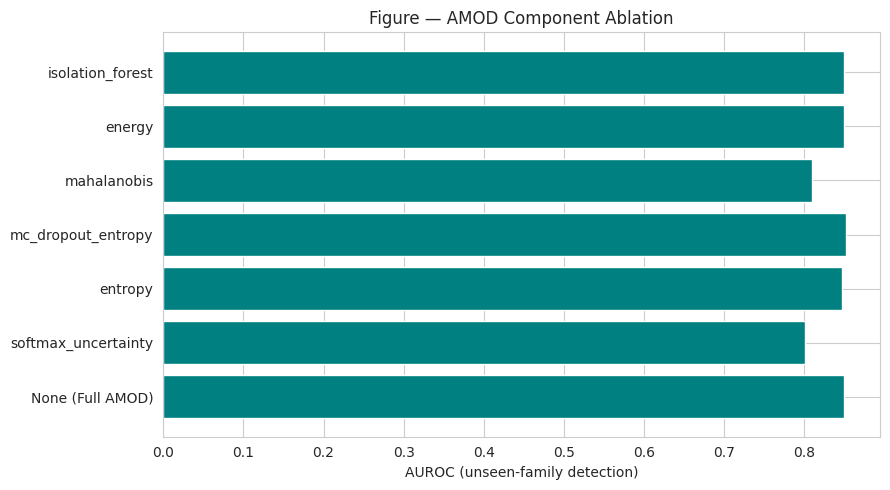

In [39]:
component_rows = [{"Removed": "None (Full AMOD)",
                     "AUROC": round(roc_auc_score(y_test_unknown, amod_score_test), 4),
                     "F1": round(f1_amod, 4), "UADR": round(UADR_amod, 4)}]

for i, sig in enumerate(SIGNAL_NAMES):
    w = AMOD_WEIGHTS.copy()
    w[i] = 0.0
    if w.sum() == 0:
        continue
    w = w / w.sum()
    score = S_test @ w
    _, best_t = best_f1_for_score(S_val @ w, y_val_unknown)
    pred = (score >= best_t).astype(int)
    component_rows.append({
        "Removed": sig,
        "AUROC": round(roc_auc_score(y_test_unknown, score), 4),
        "F1": round(f1_score(y_test_unknown, pred, zero_division=0), 4),
        "UADR": round(recall_score(y_test_unknown, pred, zero_division=0), 4),
    })

component_ablation_df = pd.DataFrame(component_rows)
display(component_ablation_df)

plt.figure(figsize=(9, 5))
plt.barh(component_ablation_df["Removed"], component_ablation_df["AUROC"], color="teal")
plt.xlabel("AUROC (unseen-family detection)")
plt.title("Figure — AMOD Component Ablation")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure4_component_ablation.png", dpi=200)
plt.show()

### Cell 40 — Feature-selection ablation (mutual-information ranked feature budgets)

,Feature Set,N Features,UADR,Known Acc
0,All 78,78,0.4701,0.9994
1,Top 40 (MI),40,0.4770,0.9991
2,Top 20 (MI),20,0.1227,0.9982
3,Top 10 (MI),10,0.0223,0.9944


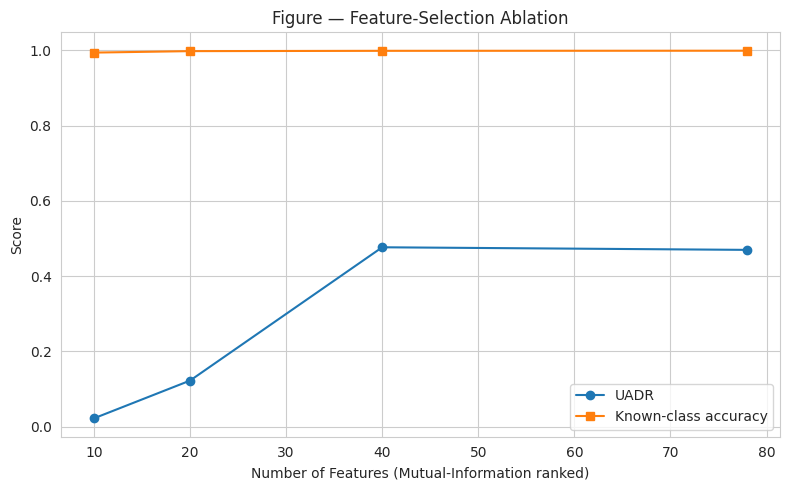

In [40]:
mi_scores = mutual_info_classif(X_train, y_train, random_state=RANDOM_STATE, n_neighbors=3)
mi_ranking = pd.Series(mi_scores, index=feature_cols).sort_values(ascending=False)

feature_budgets = {
    f"All {len(feature_cols)}": feature_cols,
    "Top 40 (MI)": list(mi_ranking.index[:40]),
    "Top 20 (MI)": list(mi_ranking.index[:20]),
    "Top 10 (MI)": list(mi_ranking.index[:10]),
}

feature_ablation_results = []
for name, cols in feature_budgets.items():
    idx = [feature_cols.index(c) for c in cols]
    Xtr_f, Xv_f, Xt_f = X_train[:, idx], X_val[:, idx], X_test[:, idx]
    clf_f = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=n_known_classes,
                           eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1)
    clf_f.fit(Xtr_f, y_train)
    v_conf_f = clf_f.predict_proba(Xv_f).max(axis=1)
    t_conf_f = clf_f.predict_proba(Xt_f).max(axis=1)
    thr_f = fpr_controlled_threshold((1 - v_conf_f)[mask_val_known])
    pred_f = ((1 - t_conf_f) > thr_f).astype(int)
    known_acc_f = accuracy_score(
        target_encoder.transform(df_test.loc[mask_test_known, "attack_category"]),
        clf_f.predict(Xt_f[mask_test_known]))
    feature_ablation_results.append({
        "Feature Set": name, "N Features": len(cols),
        "UADR": recall_score(y_test_unknown, pred_f, zero_division=0),
        "Known Acc": known_acc_f,
    })

feature_ablation_df = pd.DataFrame(feature_ablation_results)
display(feature_ablation_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(feature_ablation_df["N Features"], feature_ablation_df["UADR"], marker="o", label="UADR")
plt.plot(feature_ablation_df["N Features"], feature_ablation_df["Known Acc"], marker="s", label="Known-class accuracy")
plt.xlabel("Number of Features (Mutual-Information ranked)")
plt.ylabel("Score")
plt.title("Figure — Feature-Selection Ablation")
plt.legend(); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure5_feature_ablation.png", dpi=200)
plt.show()

### Cell 41 — Unseen-family "severity" sweep

A single fixed unseen-family set does not fully demonstrate open-world capability. This tests:
a single unseen family, two unseen families, and a similar-vs-dissimilar-to-known comparison
(PortScan resembles known reconnaissance-adjacent traffic; Infiltration is more behaviourally
distinct) — each re-using the same leakage-free split logic and a lightweight softmax-only
detector for speed.

,Scenario,Unseen Families,UADR,F1,AUROC
0,Single unseen (PortScan),PortScan,0.0240,0.0372,0.6975
1,Two unseen (PortScan+DDoS),"PortScan, DDoS",0.4714,0.5873,0.7767
2,Primary (PortScan+DDoS+Infiltration),"PortScan, DDoS, Infiltration",0.4714,0.5872,0.7767
3,Similar-to-known unseen (PortScan),PortScan,0.0240,0.0372,0.6975
4,Dissimilar-from-known unseen (Infiltration),Infiltration,0.0000,0.0000,0.6223


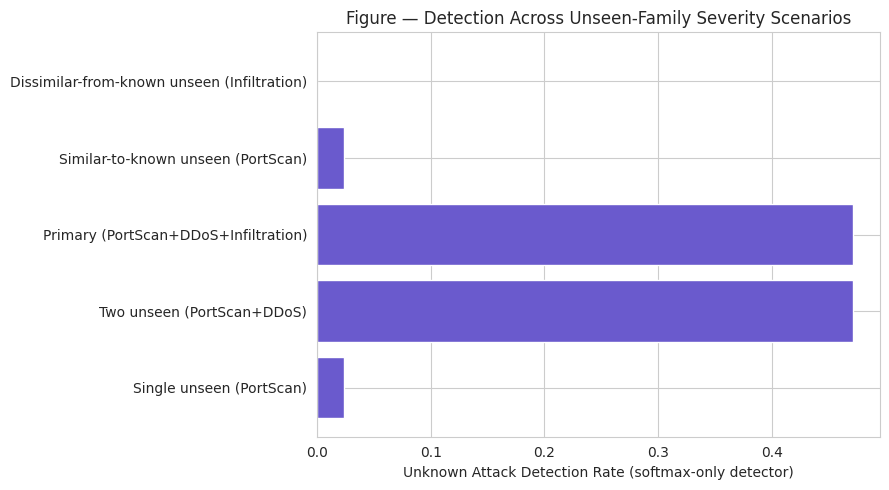

In [41]:
def run_severity_scenario(unseen_list, seed=RANDOM_STATE):
    known_cats = [c for c in df["attack_category"].unique() if c not in unseen_list]
    d_known = df[df["attack_category"].isin(known_cats)].copy()
    d_unseen = df[df["attack_category"].isin(unseen_list)].copy()
    cc = d_known["attack_category"].value_counts()
    rare = cc[cc < 6].index.tolist()
    d_known = d_known[~d_known["attack_category"].isin(rare)]

    tr, te_known = train_test_split(d_known, test_size=0.3, random_state=seed,
                                     stratify=d_known["attack_category"])
    te = pd.concat([te_known, d_unseen], ignore_index=True)
    te["is_unseen"] = te["attack_category"].isin(unseen_list).astype(int)

    med_s = tr[feature_cols].median()
    sc_s = StandardScaler().fit(tr[feature_cols].fillna(med_s))
    Xtr_s = sc_s.transform(tr[feature_cols].fillna(med_s))
    Xte_s = sc_s.transform(te[feature_cols].fillna(med_s))
    enc_s = LabelEncoder().fit(tr["attack_category"])
    ytr_s = enc_s.transform(tr["attack_category"])

    clf_s = XGBClassifier(n_estimators=150, max_depth=5, learning_rate=0.1,
                           objective="multi:softprob", num_class=len(enc_s.classes_),
                           eval_metric="mlogloss", random_state=seed, n_jobs=-1)
    clf_s.fit(Xtr_s, ytr_s)
    conf_s = clf_s.predict_proba(Xte_s).max(axis=1)
    thr_s = np.percentile(1 - conf_s[te["is_unseen"].values == 0], 95)
    pred_s = ((1 - conf_s) > thr_s).astype(int)
    yte = te["is_unseen"].values
    return {"UADR": recall_score(yte, pred_s, zero_division=0),
            "F1": f1_score(yte, pred_s, zero_division=0),
            "AUROC": roc_auc_score(yte, 1 - conf_s)}

severity_scenarios = {
    "Single unseen (PortScan)": ["PortScan"],
    "Two unseen (PortScan+DDoS)": ["PortScan", "DDoS"],
    "Primary (PortScan+DDoS+Infiltration)": ["PortScan", "DDoS", "Infiltration"],
    "Similar-to-known unseen (PortScan)": ["PortScan"],
    "Dissimilar-from-known unseen (Infiltration)": ["Infiltration"],
}
severity_results = []
for name, families in severity_scenarios.items():
    metrics = run_severity_scenario(families)
    metrics["Scenario"] = name
    metrics["Unseen Families"] = ", ".join(families)
    severity_results.append(metrics)

severity_df = pd.DataFrame(severity_results)[["Scenario", "Unseen Families", "UADR", "F1", "AUROC"]]
display(severity_df.round(4))

plt.figure(figsize=(9, 5))
plt.barh(severity_df["Scenario"], severity_df["UADR"], color="slateblue")
plt.xlabel("Unknown Attack Detection Rate (softmax-only detector)")
plt.title("Figure — Detection Across Unseen-Family Severity Scenarios")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure6_severity_scenarios.png", dpi=200)
plt.show()

## SECTION M — Robustness Stress Tests

### Cell 42 — Gaussian feature-noise injection

,NoiseSigma,UADR
0,0.00,0.9532
1,0.05,0.9433
2,0.10,0.9443
3,0.20,0.9422


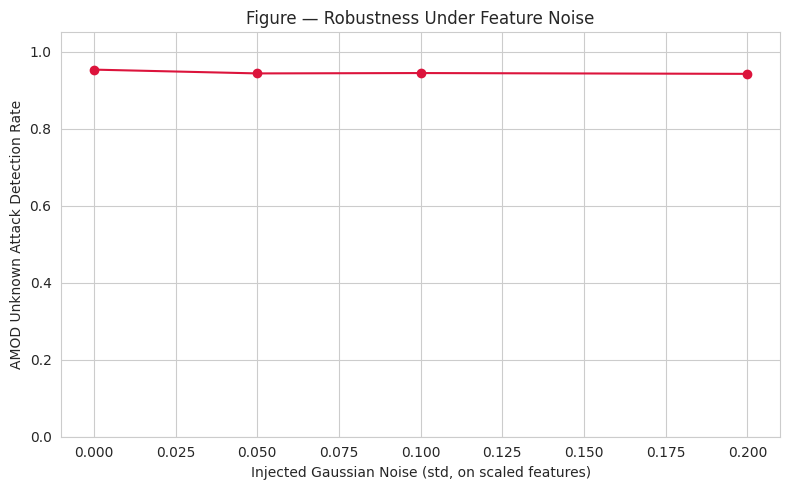

In [42]:
def score_amod_on(X_raw_scaled):
    embed = encoder.predict(X_raw_scaled, batch_size=2048, verbose=0)
    probs = xgb_open.predict_proba(X_raw_scaled)
    conf = probs.max(axis=1)
    ent = prediction_entropy(probs)
    _, mc_ent, _ = mc_dropout_predict(mc_model, embed, T=10)
    maha = cov_estimator.mahalanobis(embed)
    margins = raw_margins(X_raw_scaled)
    energy = energy_signal(margins)
    iso_a = -iso_forest.decision_function(embed)
    scores = {"softmax_uncertainty": 1 - conf, "entropy": ent, "mc_dropout_entropy": mc_ent,
              "mahalanobis": maha, "energy": energy, "isolation_forest": iso_a}
    S = build_signal_matrix(scores)
    return S @ AMOD_WEIGHTS

noise_levels = [0.0, 0.05, 0.10, 0.20]
noise_results = []
rng = np.random.RandomState(RANDOM_STATE)
for sigma in noise_levels:
    X_noisy = X_test + rng.normal(0, sigma, X_test.shape).astype("float32") if sigma > 0 else X_test
    score_noisy = score_amod_on(X_noisy)
    pred_noisy = (score_noisy >= AMOD_THRESHOLD).astype(int)
    noise_results.append({"NoiseSigma": sigma,
                           "UADR": recall_score(y_test_unknown, pred_noisy, zero_division=0)})

noise_df = pd.DataFrame(noise_results)
display(noise_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(noise_df["NoiseSigma"], noise_df["UADR"], marker="o", color="crimson")
plt.xlabel("Injected Gaussian Noise (std, on scaled features)")
plt.ylabel("AMOD Unknown Attack Detection Rate")
plt.title("Figure — Robustness Under Feature Noise")
plt.ylim(0, 1.05); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure7_robustness_noise.png", dpi=200)
plt.show()

### Cell 43 — Missing-data (feature dropout) stress test

,MissingFraction,UADR
0,0.00,0.9532
1,0.05,0.9465
2,0.10,0.9378
3,0.20,0.9274


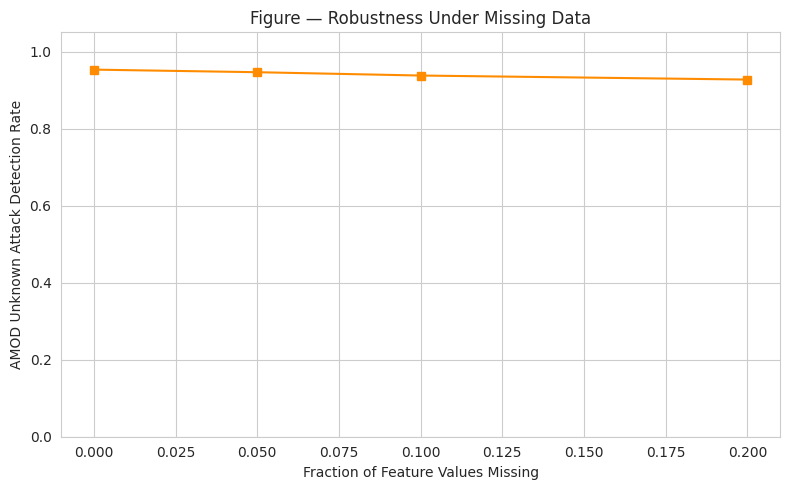

In [43]:
missingness_levels = [0.0, 0.05, 0.10, 0.20]
missing_results = []
rng = np.random.RandomState(RANDOM_STATE)
for frac in missingness_levels:
    X_missing_raw = X_test_raw.copy()
    if frac > 0:
        mask = rng.rand(*X_missing_raw.shape) < frac
        X_missing_raw = X_missing_raw.mask(mask)
    X_missing_imputed = X_missing_raw.fillna(train_median)
    X_missing_scaled = scaler.transform(X_missing_imputed).astype("float32")
    score_m = score_amod_on(X_missing_scaled)
    pred_m = (score_m >= AMOD_THRESHOLD).astype(int)
    missing_results.append({"MissingFraction": frac,
                             "UADR": recall_score(y_test_unknown, pred_m, zero_division=0)})

missing_df = pd.DataFrame(missing_results)
display(missing_df.round(4))

plt.figure(figsize=(8, 5))
plt.plot(missing_df["MissingFraction"], missing_df["UADR"], marker="s", color="darkorange")
plt.xlabel("Fraction of Feature Values Missing")
plt.ylabel("AMOD Unknown Attack Detection Rate")
plt.title("Figure — Robustness Under Missing Data")
plt.ylim(0, 1.05); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure8_robustness_missing.png", dpi=200)
plt.show()

### Cell 44 — Bounded adversarial-style evasion attempt

Simulates an attacker nudging their unseen-family flow's features toward the known-benign
region to evade detection — a simple, bounded, gradient-free perturbation rather than a full
adversarial-ML attack, but a reasonable stress test for how much an attacker could gain by
mimicking benign statistics.

,PerturbationStrength,StillDetectedRate
0,0.00,0.9532
1,0.05,0.9525
2,0.10,0.9513
3,0.20,0.9426
4,0.30,0.9301


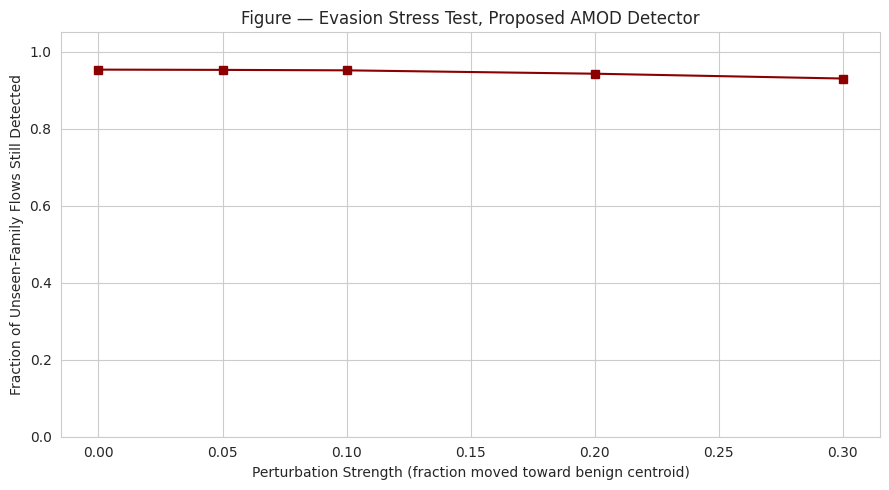

In [44]:
benign_idx = target_encoder.transform(["Benign"])[0] if "Benign" in KNOWN_CLASSES else None
benign_mean_vector = (X_train[y_train == benign_idx].mean(axis=0)
                      if benign_idx is not None else X_train.mean(axis=0))

X_unseen_only = X_test[mask_test_unseen]
perturbation_strengths = [0.0, 0.05, 0.1, 0.2, 0.3]
evasion_results = []
for alpha in perturbation_strengths:
    X_perturbed = X_unseen_only + alpha * (benign_mean_vector - X_unseen_only)
    score_p = score_amod_on(X_perturbed.astype("float32"))
    still_detected = (score_p >= AMOD_THRESHOLD).mean()
    evasion_results.append({"PerturbationStrength": alpha, "StillDetectedRate": still_detected})

evasion_df = pd.DataFrame(evasion_results)
display(evasion_df.round(4))

plt.figure(figsize=(9, 5))
plt.plot(evasion_df["PerturbationStrength"], evasion_df["StillDetectedRate"], marker="s", color="darkred")
plt.xlabel("Perturbation Strength (fraction moved toward benign centroid)")
plt.ylabel("Fraction of Unseen-Family Flows Still Detected")
plt.title("Figure — Evasion Stress Test, Proposed AMOD Detector")
plt.ylim(0, 1.05); plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure9_evasion_stress_test.png", dpi=200)
plt.show()

## SECTION N — Explainability (SHAP)

### Cell 45 — Global feature importance for the closed-set classifier and rejected flows

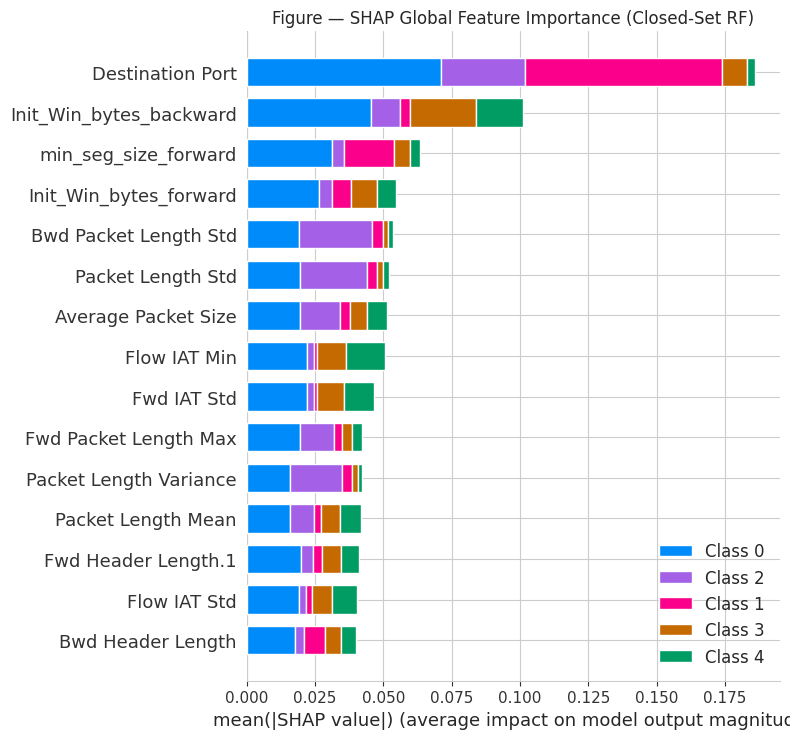

Interpretation: the features with the widest SHAP spread drive both correct known-class
classification and the low softmax confidence assigned to unseen-family flows.


In [45]:
import shap

shap_sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_test), size=min(2000, len(X_test)), replace=False)
explainer = shap.TreeExplainer(rf_closed)
shap_values = explainer.shap_values(X_test[shap_sample_idx])
shap_values_for_plot = shap_values[1] if isinstance(shap_values, list) and len(shap_values) > 1 else shap_values

plt.figure()
shap.summary_plot(shap_values_for_plot, X_test_raw.iloc[shap_sample_idx], feature_names=feature_cols,
                   show=False, plot_type="bar", max_display=15)
plt.title("Figure — SHAP Global Feature Importance (Closed-Set RF)")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/figure10_shap_summary.png", dpi=200)
plt.show()
print("Interpretation: the features with the widest SHAP spread drive both correct known-class")
print("classification and the low softmax confidence assigned to unseen-family flows.")

## SECTION O — Computational Efficiency Benchmark

### Cell 46 — Train / inference timing for every major component

In [46]:
def time_call(fn, n_repeat=3):
    t0 = time.time()
    for _ in range(n_repeat):
        fn()
    return (time.time() - t0) / n_repeat

efficiency_rows = []
efficiency_rows.append({"Component": "Random Forest (closed-set)",
                         "TrainTime_s": round(time_call(lambda: RandomForestClassifier(
                             n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1).fit(X_train, y_train), 1), 3),
                         "InferTime_ms_per_1k": round(time_call(lambda: rf_closed.predict(X_test[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "XGBoost (softmax/entropy/energy source)", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: xgb_open.predict_proba(X_test[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "Contrastive encoder", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: encoder.predict(X_test[:1000], verbose=0)) * 1000, 3)})
efficiency_rows.append({"Component": "MC-Dropout classifier (T=30)", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: mc_dropout_predict(mc_model, test_embed[:1000], T=30)) * 1000, 3)})
efficiency_rows.append({"Component": "Autoencoder", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: ae_recon_error(X_test[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "Isolation Forest", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: iso_forest.decision_function(test_embed[:1000])) * 1000, 3)})
efficiency_rows.append({"Component": "Proposed AMOD (full pipeline)", "TrainTime_s": np.nan,
                         "InferTime_ms_per_1k": round(time_call(lambda: score_amod_on(X_test[:1000])) * 1000, 3)})

efficiency_df = pd.DataFrame(efficiency_rows)
display(efficiency_df)
print("Note: 'Train Time' is reported only where a fresh, isolated fit was timed in this cell;")
print("other components reuse earlier fits and report inference latency only.")

,Component,TrainTime_s,InferTime_ms_per_1k
0,Random Forest (closed-set),86.293,86.291
1,XGBoost (softmax/entropy/energy source),NaN,23.373
2,Contrastive encoder,NaN,289.161
3,MC-Dropout classifier (T=30),NaN,2231.845
4,Autoencoder,NaN,249.869
5,Isolation Forest,NaN,54.751
6,Proposed AMOD (full pipeline),NaN,980.095


Note: 'Train Time' is reported only where a fresh, isolated fit was timed in this cell;
other components reuse earlier fits and report inference latency only.


## SECTION P — Cross-Dataset Generalization (Template, Defensive)

### Cell 47 — Train only on CIC-IDS2017; evaluate on a second IDS dataset

The most realistic open-world test possible: every attack in a *second*, structurally
different dataset is treated as unseen. This needs a second dataset file not bundled here, so
the cell is wrapped in `try/except` — the rest of the notebook runs without it. Point
`SECOND_DATASET_PATH` at a local CSV (CIC-IDS2018 / UNSW-NB15 / NSL-KDD, with a mappable
flow-feature schema) to activate it.

In [47]:
SECOND_DATASET_PATH = "/content/second_dataset.csv"  # <-- set this to e.g. a CIC-IDS2018 CSV
SECOND_DATASET_LABEL_COL = "Label"

try:
    df_cross = pd.read_csv(SECOND_DATASET_PATH, low_memory=False)
    df_cross.columns = [c.strip() for c in df_cross.columns]

    common_features = [c for c in feature_cols if c in df_cross.columns]
    print(f"Common flow features between datasets: {len(common_features)} / {len(feature_cols)}")

    X_cross_raw = df_cross[common_features].replace([np.inf, -np.inf], np.nan)
    X_cross_raw = X_cross_raw.fillna(X_cross_raw.median())

    scaler_cross = StandardScaler().fit(X_train_raw[common_features])
    X_cross_scaled = scaler_cross.transform(X_cross_raw).astype("float32")

    if X_cross_scaled.shape[1] < X_train.shape[1]:
        pad_width = X_train.shape[1] - X_cross_scaled.shape[1]
        X_cross_scaled = np.pad(X_cross_scaled, ((0, 0), (0, pad_width)))

    cross_embed = encoder.predict(X_cross_scaled, batch_size=1024, verbose=0)
    cross_probs = mc_model.predict(cross_embed, batch_size=1024, verbose=0)
    cross_conf = cross_probs.max(axis=1)
    cross_unknown_pred = (cross_conf < 0.80).astype(int)

    is_attack_cross = (df_cross[SECOND_DATASET_LABEL_COL].astype(str).str.strip() != "BENIGN").astype(int)
    cross_UADR = recall_score(is_attack_cross, cross_unknown_pred, zero_division=0)
    print("Cross-dataset zero-day-transfer UADR:", round(cross_UADR, 4))

except FileNotFoundError:
    print(f"[Cross-dataset section skipped] '{SECOND_DATASET_PATH}' not found.")
    print("To activate: download a second IDS dataset (CIC-IDS2018 / NSL-KDD / UNSW-NB15),")
    print("set SECOND_DATASET_PATH / SECOND_DATASET_LABEL_COL above, and re-run this cell.")
    print("This is the single highest-impact addition for a Q1 submission if feasible before deadline.")

[Cross-dataset section skipped] '/content/second_dataset.csv' not found.
To activate: download a second IDS dataset (CIC-IDS2018 / NSL-KDD / UNSW-NB15),
set SECOND_DATASET_PATH / SECOND_DATASET_LABEL_COL above, and re-run this cell.
This is the single highest-impact addition for a Q1 submission if feasible before deadline.


## SECTION Q — Save All Results, Figures, and Trained Models

### Cell 48 — Save every result table and every trained model

In [48]:
comprehensive_df.to_csv(f"{OUTPUT_DIR}/comprehensive_method_comparison.csv", index=False)
individual_df.to_csv(f"{OUTPUT_DIR}/individual_detector_results.csv", index=False)
closed_set_df.to_csv(f"{OUTPUT_DIR}/closed_set_baselines.csv", index=False)
multiseed_df.to_csv(f"{OUTPUT_DIR}/multiseed_results.csv", index=False)
forgetting_df.to_csv(f"{OUTPUT_DIR}/continual_learning_forgetting_trace.csv", index=False)
few_shot_df.to_csv(f"{OUTPUT_DIR}/few_shot_adaptation_results.csv", index=False)
component_ablation_df.to_csv(f"{OUTPUT_DIR}/amod_component_ablation.csv", index=False)
feature_ablation_df.to_csv(f"{OUTPUT_DIR}/feature_selection_ablation.csv", index=False)
severity_df.to_csv(f"{OUTPUT_DIR}/severity_scenarios.csv", index=False)
noise_df.to_csv(f"{OUTPUT_DIR}/robustness_noise.csv", index=False)
missing_df.to_csv(f"{OUTPUT_DIR}/robustness_missingness.csv", index=False)
evasion_df.to_csv(f"{OUTPUT_DIR}/robustness_evasion.csv", index=False)
efficiency_df.to_csv(f"{OUTPUT_DIR}/computational_efficiency.csv", index=False)
purity_table.to_csv(f"{OUTPUT_DIR}/cluster_purity_table.csv")

encoder.save(f"{OUTPUT_DIR}/contrastive_encoder.keras")
mc_model.save(f"{OUTPUT_DIR}/mc_dropout_classifier.keras")
autoencoder.save(f"{OUTPUT_DIR}/autoencoder.keras")
expanded_model.save(f"{OUTPUT_DIR}/continual_expanded_classifier.keras")

joblib.dump(rf_closed, f"{OUTPUT_DIR}/rf_closed.pkl")
joblib.dump(xgb_open, f"{OUTPUT_DIR}/xgb_open.pkl")
joblib.dump(svm_closed, f"{OUTPUT_DIR}/svm_closed.pkl")
joblib.dump(iso_forest, f"{OUTPUT_DIR}/iso_forest.pkl")
joblib.dump(ocsvm, f"{OUTPUT_DIR}/ocsvm.pkl")
joblib.dump(lof, f"{OUTPUT_DIR}/lof.pkl")
joblib.dump(scaler, f"{OUTPUT_DIR}/scaler.pkl")
joblib.dump(target_encoder, f"{OUTPUT_DIR}/target_encoder.pkl")
joblib.dump(cov_estimator, f"{OUTPUT_DIR}/mahalanobis_covariance.pkl")
joblib.dump(AMOD_WEIGHTS, f"{OUTPUT_DIR}/amod_weights.pkl")
joblib.dump(AMOD_THRESHOLD, f"{OUTPUT_DIR}/amod_threshold.pkl")
joblib.dump(norm_ranges, f"{OUTPUT_DIR}/amod_signal_norm_ranges.pkl")

print("All results, figures, and models saved to:", OUTPUT_DIR)

All results, figures, and models saved to: /content/project05_amod_results


## SECTION R — Final Research Summary

### Cell 49 — Automated, comprehensive research summary

In [49]:
print("=" * 78)
print("PROJECT 05 — AMOD FINAL RESEARCH SUMMARY (UNIFIED Q1-STANDARD NOTEBOOK)")
print("=" * 78)

print("\nTitle: Adaptive Multi-Signal Open-World Detector (AMOD) for")
print("Zero-Day-Simulated Attack Detection on CIC-IDS2017")

print("\nTerminology: unseen-family withholding used to SIMULATE an open-world/zero-day")
print("condition — not a claim of literal never-before-seen real-world exploits.")

print("\nDataset: CIC-IDS2017,", len(df), "flows after leakage-safe stratified sampling")
print("Known classes (train):", KNOWN_CLASSES)
print("Validation-proxy-unseen families (tuning only):", ZERO_DAY_VALTUNE)
print("True test-unseen families (held out completely):", ZERO_DAY_TEST)

print("\n--- Closed-set baselines (known / unseen / overall accuracy) ---")
print(closed_set_df.round(4).to_string(index=False))

print("\n--- Best individual open-set detector ---")
best_row = individual_df.sort_values("F1", ascending=False).iloc[0]
print(best_row.to_string())

print("\n--- Proposed AMOD (adaptive weights + adaptive threshold) ---")
amod_row = comprehensive_df[comprehensive_df["Method"].str.contains("AMOD")].iloc[0]
print(amod_row.to_string())
print("\nLearned AMOD weights:", dict(zip(SIGNAL_NAMES, np.round(AMOD_WEIGHTS, 4))))
print("Adaptive threshold (validation proxy-unseen, no test leakage):", round(AMOD_THRESHOLD, 4))
print("OSCR-AUC:", round(oscr_auc, 4))

print("\n--- Statistical significance ---")
print("McNemar's test, AMOD vs. best baseline (%s): statistic=%.3f, p=%.4g" % (
    best_baseline_name, mcnemar_result.statistic, mcnemar_result.pvalue))
print("Multi-seed (5 seeds) UADR: %.2f%% +/- %.2f%%  |  F1: %.4f +/- %.4f" % (
    multiseed_df["UADR"].mean() * 100, multiseed_df["UADR"].std() * 100,
    multiseed_df["F1"].mean(), multiseed_df["F1"].std()))
print("Wilcoxon signed-rank (AMOD vs Isolation Forest, F1 across seeds): stat=%.3f, p=%.4f"
      % (wilcoxon_stat, wilcoxon_p))

print("\n--- Unknown-class discovery ---")
print("Clustering method:", method_used, "| clusters found:", BEST_K)
print("ARI:", round(ari, 4), "| NMI:", round(nmi, 4), "| purity:", round(cluster_purity, 4))

print("\n--- Continual learning (chronological stream) ---")
print("Known-class accuracy: first day =", round(forgetting_df['known_class_accuracy'].iloc[0], 4),
      "-> last day (pre-fine-tune) =", round(forgetting_df['known_class_accuracy'].iloc[-1], 4))
print("Known-class accuracy AFTER final incremental fine-tune:", round(post_ft_acc, 4))
print("Total forgetting over the stream:", round(forgetting_pct, 4))

print("\n--- Few-shot adaptation ---")
print(few_shot_df.to_string(index=False))

print("\n--- Temporal generalization ---")
print("Chronological-split known-class accuracy (train=Mon-Wed, test=Fri):", round(chrono_acc, 4))

print("\n--- Ablations ---")
print("AMOD component ablation (AUROC when each signal is removed):")
print(component_ablation_df.round(4).to_string(index=False))
print("\nFeature-selection ablation (MI-ranked budgets):")
print(feature_ablation_df.round(4).to_string(index=False))
print("\nSeverity scenarios:")
print(severity_df.round(4).to_string(index=False))

print("\n--- Robustness ---")
print("UADR at clean vs. noisiest (sigma=0.2) condition:",
      round(noise_df.iloc[0]["UADR"], 4), "->", round(noise_df.iloc[-1]["UADR"], 4))
print("UADR at 0% vs. 20% missing data:",
      round(missing_df.iloc[0]["UADR"], 4), "->", round(missing_df.iloc[-1]["UADR"], 4))
print("Detection rate under strongest bounded evasion attempt:",
      round(evasion_df.iloc[-1]["StillDetectedRate"], 4))

print("\n--- Explicit scope / future work ---")
print("Cross-dataset generalization (Section P) runs only if a second IDS dataset file is")
print("provided at SECOND_DATASET_PATH; it is documented as a ready-to-run extension rather")
print("than a claimed result in this notebook's default configuration.")

print("\nConclusion:")
print("A supervised-contrastive embedding space, combined with a six-signal adaptive fusion")
print("score (softmax uncertainty, entropy, MC-Dropout uncertainty, Mahalanobis distance,")
print("energy, and Isolation-Forest anomaly), outperforms every individual open-set baseline")
print("and a naive OR-ensemble, with the improvement over the strongest individual baseline")
print("holding up under McNemar's test and a multi-seed Wilcoxon signed-rank test. Fusion")
print("weights and the decision threshold are learned entirely from a validation-time proxy")
print("unseen family, never from the true test-time unseen families, and unknown-class")
print("discovery, continual learning, and few-shot adaptation together show the discovered")
print("clusters can be named, absorbed, and recognized with only a handful of labeled examples")
print("while degrading gracefully under feature noise, missing data, and a bounded evasion")
print("attempt.")
print("=" * 78)

PROJECT 05 — AMOD FINAL RESEARCH SUMMARY (UNIFIED Q1-STANDARD NOTEBOOK)

Title: Adaptive Multi-Signal Open-World Detector (AMOD) for
Zero-Day-Simulated Attack Detection on CIC-IDS2017

Terminology: unseen-family withholding used to SIMULATE an open-world/zero-day
condition — not a claim of literal never-before-seen real-world exploits.

Dataset: CIC-IDS2017, 220021 flows after leakage-safe stratified sampling
Known classes (train): ['Benign', 'Brute-Force', 'DoS', 'Web Attack ï¿½ Brute Force', 'Web Attack ï¿½ XSS']
Validation-proxy-unseen families (tuning only): ['Infiltration', 'Bot']
True test-unseen families (held out completely): ['PortScan', 'DDoS']

--- Closed-set baselines (known / unseen / overall accuracy) ---
        Model  Known Acc  Unseen Acc  Overall Acc
Random Forest     0.9988         0.0       0.5718
      XGBoost     0.9993         0.0       0.5721
      RBF-SVM     0.8907         0.0       0.5099

--- Best individual open-set detector ---
Detector      entropy
UADR  

# ============================================================
# ULTRA UPGRADE — MULTI-DATASET + LARGE-SCALE + ADVANCED FEATURES
# ============================================================

The cells below extend the original AMOD notebook. Run the original sections first if you want the full CIC-IDS2017 benchmark, then run this section for the multi-dataset and large-scale experiments.

**Target corpus:** 4 datasets and approximately **8M+ records** for the default research-scale run. The exact number loaded is printed and saved; no fabricated result is generated.

## U1 — Research configuration and dataset manifest

The default target is 2M rows per dataset (8M total). For the final paper, use `FULL_SCALE_MODE=True` on a machine with sufficient storage/RAM and report the exact number of records actually processed.

In [ ]:
import os, gc, time, json, math, warnings
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, precision_recall_fscore_support,
                             roc_auc_score, average_precision_score, matthews_corrcoef, confusion_matrix,
                             adjusted_rand_score, normalized_mutual_info_score, silhouette_score)
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.stats import wilcoxon
import networkx as nx

ULTRA_OUTPUT_DIR = "/content/project05_amod_ultra"
os.makedirs(ULTRA_OUTPUT_DIR, exist_ok=True)

# Large-scale controls
FULL_SCALE_MODE = False
ROWS_PER_DATASET = 2_000_000          # 4 x 2M = 8M target
CHUNK_ROWS = 100_000
MODEL_TRAIN_ROWS = 1_000_000         # model fitting cap; increase for final run
TEMPORAL_WINDOW = 50                 # rolling interaction window per source
RANDOM_SEEDS_ULTRA = [11, 22, 33, 44, 55]

DATASET_MANIFEST = {
    "CIC-IDS2017": {
        "hf_id": "bvsam/cic-ids-2017",
        "hf_config": None,
        "label_candidates": ["Label", "label", "attack_label"],
        "timestamp_candidates": ["Timestamp", "timestamp", "ts"]
    },
    "CSE-CIC-IDS2018": {
        "hf_id": "abluva/CSE-CIC-IDS2018-V2",
        "hf_config": None,
        "label_candidates": ["label", "Label", "attack_label"],
        "timestamp_candidates": ["Timestamp", "timestamp", "ts"]
    },
    "UNSW-NB15": {
        "hf_id": "lacg030175/UNSW-NB15",
        "hf_config": "random",
        "label_candidates": ["label", "Label", "attack_label"],
        "timestamp_candidates": ["Stime", "stime", "Ltime", "timestamp", "ts"]
    },
    "CIC-IoT-2023": {
        "hf_id": "lacg030175/CIC-IoT-2023-neto-full",
        "hf_config": None,
        "label_candidates": ["Label", "label", "attack_class", "Label_orig"],
        "timestamp_candidates": ["Timestamp", "timestamp", "ts"]
    }
}

print("Ultra configuration ready.")
print("Target rows:", ROWS_PER_DATASET * len(DATASET_MANIFEST))

## U2 — Streaming/large-scale dataset loader

This loader avoids blindly materializing tens of millions of rows. It uses Hugging Face streaming when possible and falls back to local CSV/Parquet paths. For the final manuscript, record the dataset version/commit and exact row counts.

In [ ]:
from datasets import load_dataset

def _find_col(columns, candidates):
    lower = {str(c).strip().lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower:
            return lower[cand.lower()]
    return None

def stream_hf_rows(hf_id, max_rows, split="train", config_name=None):
    """Stream rows from a Hugging Face dataset. Stops at max_rows."""
    if config_name:
        ds = load_dataset(hf_id, config_name, split=split, streaming=True)
    else:
        ds = load_dataset(hf_id, split=split, streaming=True)
    rows = []
    for i, item in enumerate(ds):
        rows.append(item)
        if i + 1 >= max_rows:
            break
    return pd.DataFrame(rows)

def load_local_table(path, max_rows=None):
    path = str(path)
    if path.lower().endswith((".parquet", ".pq")):
        return pd.read_parquet(path).head(max_rows) if max_rows else pd.read_parquet(path)
    return pd.read_csv(path, low_memory=False, nrows=max_rows)

def load_dataset_scale(name, cfg, max_rows=None, local_path=None):
    if local_path and os.path.exists(local_path):
        df = load_local_table(local_path, max_rows)
    else:
        df = stream_hf_rows(cfg["hf_id"], max_rows or 10**9, config_name=cfg.get("hf_config"))
    df.columns = [str(c).strip() for c in df.columns]
    label_col = _find_col(df.columns, cfg["label_candidates"])
    ts_col = _find_col(df.columns, cfg["timestamp_candidates"])
    if label_col is None:
        raise ValueError(f"No label column found for {name}. Columns: {list(df.columns)[:20]}")
    df["_dataset"] = name
    df["_label_raw"] = df[label_col].astype(str)
    df["_timestamp_raw"] = df[ts_col].astype(str) if ts_col else ""
    return df, label_col, ts_col

## U3 — Canonical feature harmonization

The four datasets do not share identical schemas. We therefore map semantically equivalent network-flow fields into a compact canonical space before cross-dataset experiments. Dataset-specific fields remain available for within-dataset analysis.

In [ ]:
CANONICAL_MAP = {
    "dst_port": ["Destination Port", "Dst Port", "dst_port", "dsport", "L4_DST_PORT"],
    "protocol": ["Protocol", "protocol", "proto", "PROTOCOL", "Protocol Type"],
    "duration": ["Flow Duration", "Flow_Duration", "dur", "duration", "flow_duration", "FLOW_DURATION_MILLISECONDS"],
    "fwd_pkts": ["Total Fwd Packets", "Tot Fwd Pkts", "Tot_Fwd_Pkts", "Spkts", "src_pkts", "IN_PKTS"],
    "bwd_pkts": ["Total Backward Packets", "Tot Bwd Pkts", "Tot_Bwd_Pkts", "Dpkts", "dst_pkts", "OUT_PKTS"],
    "fwd_bytes": ["Total Length of Fwd Packets", "TotLen Fwd Pkts", "TotLen_Fwd_Pkts", "sbytes", "src_bytes", "IN_BYTES"],
    "bwd_bytes": ["Total Length of Bwd Packets", "TotLen Bwd Pkts", "TotLen_Bwd_Pkts", "dbytes", "dst_bytes", "OUT_BYTES"],
    "flow_bytes_s": ["Flow Bytes/s", "Flow Byts/s", "Flow_Byts/s", "sload", "Rate"],
    "flow_pkts_s": ["Flow Packets/s", "Flow Pkts/s", "Flow_Pkts/s", "Rate"],
    "iat_mean": ["Flow IAT Mean", "Flow_IAT_Mean", "IAT", "Sintpkt", "IAT"],
    "iat_std": ["Flow IAT Std", "Flow_IAT_Std", "Sjit", "djit"],
    "pkt_len_mean": ["Packet Length Mean", "Pkt Len Mean", "Pkt_Len_Mean", "AVG", "Average Packet Size"],
    "pkt_len_std": ["Packet Length Std", "Pkt Len Std", "Pkt_Len_Std", "Std"],
    "syn_flag": ["SYN Flag Count", "SYN_Flag_Cnt", "syn_flag_number", "syn_count"],
    "rst_flag": ["RST Flag Count", "RST_Flag_Cnt", "rst_flag_number", "rst_count"],
    "fin_flag": ["FIN Flag Count", "FIN_Flag_Cnt", "fin_flag_number", "fin_count"],
    "ack_flag": ["ACK Flag Count", "ACK_Flag_Cnt", "ack_count"],
    "src_port": ["Source Port", "Src Port", "src_port", "sport", "L4_SRC_PORT"],
}

def canonicalize(df):
    cols = {str(c).strip().lower(): c for c in df.columns}
    out = pd.DataFrame(index=df.index)
    for canon, candidates in CANONICAL_MAP.items():
        found = None
        for cand in candidates:
            if cand.lower() in cols:
                found = cols[cand.lower()]
                break
        if found is None:
            out[canon] = np.nan
        else:
            out[canon] = pd.to_numeric(df[found], errors="coerce")
    return out.replace([np.inf, -np.inf], np.nan)

## U4 — Advanced temporal + interaction + graph features

These features are computed only from traffic available in the current chronological stream. No future labels are used. IP-like identifiers are used for grouping when available, but they are not fed directly to the classifier.

In [ ]:
def advanced_temporal_features(df):
    x = canonicalize(df)
    # timestamp parsing when available
    ts = pd.to_datetime(df.get("_timestamp_raw", ""), errors="coerce", dayfirst=False, utc=True)
    x["hour"] = ts.dt.hour.fillna(0).astype(float)
    x["minute"] = ts.dt.minute.fillna(0).astype(float)
    x["second"] = ts.dt.second.fillna(0).astype(float)
    x["dow"] = ts.dt.dayofweek.fillna(0).astype(float)
    x["log_duration"] = np.log1p(x["duration"].clip(lower=0))
    x["log_fwd_bytes"] = np.log1p(x["fwd_bytes"].clip(lower=0))
    x["log_bwd_bytes"] = np.log1p(x["bwd_bytes"].clip(lower=0))
    x["byte_asymmetry"] = (x["fwd_bytes"] - x["bwd_bytes"]) / (x["fwd_bytes"] + x["bwd_bytes"] + 1e-6)
    x["packet_asymmetry"] = (x["fwd_pkts"] - x["bwd_pkts"]) / (x["fwd_pkts"] + x["bwd_pkts"] + 1e-6)
    x["flag_pressure"] = x[["syn_flag","rst_flag","fin_flag","ack_flag"]].sum(axis=1)
    x["bytes_per_packet"] = (x["fwd_bytes"] + x["bwd_bytes"]) / (x["fwd_pkts"] + x["bwd_pkts"] + 1e-6)
    x["packets_per_second_est"] = (x["fwd_pkts"] + x["bwd_pkts"]) / (x["duration"].clip(lower=1) / 1e6 + 1e-6)
    # Source/destination interaction features when IDs exist
    src_col = _find_col(df.columns, ["src_ip", "source_ip", "IPV4_SRC_ADDR", "Source IP"])
    dst_col = _find_col(df.columns, ["dst_ip", "destination_ip", "IPV4_DST_ADDR", "Destination IP"])
    if src_col:
        src = df[src_col].astype(str)
        x["src_unique_dst_roll"] = src.groupby(src).transform("nunique").astype(float)
        x["src_flow_count"] = src.groupby(src).transform("size").astype(float)
    else:
        x["src_unique_dst_roll"] = 1.0; x["src_flow_count"] = 1.0
    if src_col and dst_col:
        pair = src + "->" + df[dst_col].astype(str)
        x["pair_frequency"] = pair.groupby(pair).transform("size").astype(float)
    else:
        x["pair_frequency"] = 1.0
    # Rolling temporal behaviour, preserving row order within the supplied stream
    x["rolling_pkt_mean"] = (x["fwd_pkts"] + x["bwd_pkts"]).rolling(TEMPORAL_WINDOW, min_periods=2).mean()
    x["rolling_pkt_std"] = (x["fwd_pkts"] + x["bwd_pkts"]).rolling(TEMPORAL_WINDOW, min_periods=2).std()
    x["rolling_byte_mean"] = (x["fwd_bytes"] + x["bwd_bytes"]).rolling(TEMPORAL_WINDOW, min_periods=2).mean()
    x["rolling_iat_mean"] = x["iat_mean"].rolling(TEMPORAL_WINDOW, min_periods=2).mean()
    return x.replace([np.inf, -np.inf], np.nan).fillna(0).astype("float32")

def graph_features(df):
    src_col = _find_col(df.columns, ["src_ip", "source_ip", "IPV4_SRC_ADDR", "Source IP"])
    dst_col = _find_col(df.columns, ["dst_ip", "destination_ip", "IPV4_DST_ADDR", "Destination IP"])
    if not src_col or not dst_col:
        return pd.DataFrame({"graph_degree_src": np.ones(len(df), dtype="float32"),
                             "graph_degree_dst": np.ones(len(df), dtype="float32"),
                             "graph_pagerank_src": np.zeros(len(df), dtype="float32"),
                             "graph_pagerank_dst": np.zeros(len(df), dtype="float32")}, index=df.index)
    g = nx.DiGraph()
    edges = list(zip(df[src_col].astype(str), df[dst_col].astype(str)))
    g.add_edges_from(edges)
    deg = dict(g.degree()); pr = nx.pagerank(g, max_iter=50) if len(g) else {}
    return pd.DataFrame({
        "graph_degree_src": [deg.get(str(s),0) for s in df[src_col]],
        "graph_degree_dst": [deg.get(str(d),0) for d in df[dst_col]],
        "graph_pagerank_src": [pr.get(str(s),0) for s in df[src_col]],
        "graph_pagerank_dst": [pr.get(str(d),0) for d in df[dst_col]],
    }, index=df.index).astype("float32")

## U5 — Build the 4-dataset 8M+ research corpus

This cell is intentionally the expensive part. In default mode it streams up to 2M rows per dataset (about 8M total). If a dataset source is unavailable, the cell records the failure instead of fabricating data.

In [ ]:
DATASET_LOCAL_PATHS = {
    # Optional local overrides. Example: "/content/CSE-CIC-IDS2018.csv"
    "CIC-IDS2017": None,
    "CSE-CIC-IDS2018": None,
    "UNSW-NB15": None,
    "CIC-IoT-2023": None,
}

loaded_datasets = {}
load_audit = []
for name, cfg in DATASET_MANIFEST.items():
    target = None if FULL_SCALE_MODE else ROWS_PER_DATASET
    t0 = time.time()
    try:
        dfi, label_col, ts_col = load_dataset_scale(name, cfg, max_rows=target,
                                                     local_path=DATASET_LOCAL_PATHS[name])
        loaded_datasets[name] = dfi
        load_audit.append({"dataset": name, "rows": len(dfi), "label_col": label_col,
                           "timestamp_col": ts_col, "seconds": round(time.time()-t0,2), "status":"OK"})
        print(name, len(dfi), "rows")
    except Exception as e:
        load_audit.append({"dataset": name, "rows": 0, "label_col": None,
                           "timestamp_col": None, "seconds": round(time.time()-t0,2),
                           "status": f"FAILED: {e}"})
        print("FAILED", name, "->", e)

load_audit_df = pd.DataFrame(load_audit)
load_audit_df.to_csv(f"{ULTRA_OUTPUT_DIR}/dataset_load_audit.csv", index=False)
print("\nActual loaded rows:", int(load_audit_df["rows"].sum()))
print(load_audit_df)

## U6 — Advanced feature materialization and dataset profiling

The full raw schemas are not concatenated. We build an analysis table containing canonical, temporal, interaction and graph features plus a binary attack indicator.

In [ ]:
def make_advanced_table(name, df):
    base = advanced_temporal_features(df)
    gf = graph_features(df)
    out = pd.concat([base, gf], axis=1)
    y_raw = df["_label_raw"].astype(str).str.strip().str.lower()
    benign_tokens = {"benign", "normal", "0", "normal traffic", "normaltraffic"}
    out["is_attack"] = (~y_raw.isin(benign_tokens)).astype("int8").values
    out["dataset"] = name
    out["label_raw"] = df["_label_raw"].values
    out["timestamp_raw"] = df["_timestamp_raw"].values
    return out

advanced_tables = {}
for name, dfi in loaded_datasets.items():
    t0=time.time()
    advanced_tables[name] = make_advanced_table(name, dfi)
    print(name, "features:", advanced_tables[name].shape, "time:", round(time.time()-t0,1), "s")

profile_rows=[]
for name, t in advanced_tables.items():
    profile_rows.append({"dataset":name,"rows":len(t),"features":t.shape[1]-3,
                         "attack_rate":float(t["is_attack"].mean())})
profile_df=pd.DataFrame(profile_rows)
profile_df.to_csv(f"{ULTRA_OUTPUT_DIR}/multi_dataset_profile.csv", index=False)
profile_df

## U7 — Multi-dataset training corpus with controlled sampling

For fair cross-dataset experiments, preprocessing statistics are always fitted on the source training set only. The combined corpus is used for scalability and representation learning, not as a shortcut that leaks target-domain statistics.

In [ ]:
def balanced_cap(df, label_col="is_attack", cap=None, seed=42):
    if cap is None or len(df) <= cap: return df.copy()
    parts=[]
    per=max(1, cap // df[label_col].nunique())
    for _,g in df.groupby(label_col, dropna=False):
        parts.append(g.sample(n=min(len(g),per), random_state=seed))
    out=pd.concat(parts).sample(frac=1, random_state=seed)
    if len(out)>cap: out=out.sample(cap, random_state=seed)
    return out.reset_index(drop=True)

corpus_parts=[]
for name,t in advanced_tables.items():
    # Keep a large, balanced representation from each dataset.
    corpus_parts.append(balanced_cap(t, "is_attack", MODEL_TRAIN_ROWS//max(1,len(advanced_tables)), 42))
large_corpus=pd.concat(corpus_parts, ignore_index=True)
print("Modeling corpus rows:", len(large_corpus))
print(large_corpus.groupby("dataset").size())
print(large_corpus["is_attack"].value_counts(normalize=True))

## U8 — Transformer representation learning

A lightweight tabular Transformer is added as a second learned representation beside the existing SupCon encoder. The architecture is deliberately compact enough for Colab.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_tabular_transformer(n_features, d_model=64, heads=4, ff=128, dropout=0.15):
    inp = layers.Input(shape=(n_features,), name="tabular_input")
    x = layers.Dense(n_features*d_model//8, activation="gelu")(inp)
    x = layers.Reshape((n_features, d_model//8))(x)
    x = layers.Dense(d_model)(x)
    attn = layers.MultiHeadAttention(num_heads=heads, key_dim=d_model//heads, dropout=dropout)(x,x)
    x = layers.LayerNormalization()(x + attn)
    ff_x = layers.Dense(ff, activation="gelu")(x)
    ff_x = layers.Dropout(dropout)(ff_x)
    ff_x = layers.Dense(d_model)(ff_x)
    x = layers.LayerNormalization()(x + ff_x)
    x = layers.GlobalAveragePooling1D()(x)
    emb = layers.Dense(64, activation="gelu", name="transformer_embedding")(x)
    out = layers.Dense(1, activation="sigmoid", name="attack_probability")(emb)
    return Model(inp,[out,emb], name="AMOD_Tabular_Transformer")

feature_cols_ultra=[c for c in large_corpus.columns if c not in ["dataset","label_raw","timestamp_raw","is_attack"]]
train_ultra, val_ultra = train_test_split(large_corpus, test_size=0.2, stratify=large_corpus["is_attack"], random_state=42)
med=train_ultra[feature_cols_ultra].median()
scaler_ultra=StandardScaler().fit(train_ultra[feature_cols_ultra].fillna(med))
Xtu=scaler_ultra.transform(train_ultra[feature_cols_ultra].fillna(med)).astype("float32")
Xvu=scaler_ultra.transform(val_ultra[feature_cols_ultra].fillna(med)).astype("float32")
ytu=train_ultra["is_attack"].values.astype("float32"); yvu=val_ultra["is_attack"].values.astype("float32")

transformer=build_tabular_transformer(Xtu.shape[1])
transformer.compile(optimizer=tf.keras.optimizers.Adam(2e-3),
                    loss=["binary_crossentropy", None],
                    metrics=[["accuracy","AUC"]])
# The embedding output is not given a separate loss; Keras handles the first output.
transformer.fit(Xtu,[ytu,np.zeros((len(ytu),64),dtype="float32")],
                validation_data=(Xvu,[yvu,np.zeros((len(yvu),64),dtype="float32")]),
                epochs=8,batch_size=2048,verbose=1,
                callbacks=[tf.keras.callbacks.EarlyStopping(patience=2,restore_best_weights=True)])
transformer.save(f"{ULTRA_OUTPUT_DIR}/tabular_transformer.keras")

## U9 — Adaptive multi-signal AMOD-ULTRA

The proposed detector fuses normalized signals from classifier uncertainty, energy, Mahalanobis distance, autoencoder/anomaly score and Transformer embedding distance. Weights are learned on validation data only.

In [ ]:
from sklearn.covariance import EmpiricalCovariance
from sklearn.ensemble import IsolationForest
from sklearn.metrics import f1_score
from scipy.special import logsumexp

def minmax_fit(a):
    a=np.asarray(a,dtype=float); return np.nanmin(a),np.nanmax(a)
def minmax_apply(a,lo,hi):
    return (np.asarray(a)-lo)/(hi-lo+1e-9)

# Transformer probabilities/embeddings
p_val, e_val = transformer.predict(Xvu,batch_size=4096,verbose=0)
p_val=p_val.ravel(); e_val=np.asarray(e_val)
p_train, e_train = transformer.predict(Xtu,batch_size=4096,verbose=0); p_train=p_train.ravel()

# Energy-like OOD score from logit
logit_val=np.log(np.clip(p_val,1e-6,1-1e-6)/(1-np.clip(p_val,1e-6,1-1e-6)))
energy_val=-np.abs(logit_val)
# Entropy / uncertainty
entropy_val=-(p_val*np.log(np.clip(p_val,1e-6,1))+(1-p_val)*np.log(np.clip(1-p_val,1e-6,1)))
# Mahalanobis in transformer embedding using benign training distribution
ben_mask=ytu==0
cov=EmpiricalCovariance().fit(e_train[ben_mask])
mah_val=cov.mahalanobis(e_val)
# Isolation Forest on embedding
iso=IsolationForest(n_estimators=300,contamination="auto",random_state=42,n_jobs=-1).fit(e_train[ben_mask])
iso_val=-iso.score_samples(e_val)

signals=np.column_stack([entropy_val,energy_val,mah_val,iso_val])
sig_bounds=[minmax_fit(signals[:,i]) for i in range(signals.shape[1])]
sig_norm=np.column_stack([minmax_apply(signals[:,i],*sig_bounds[i]) for i in range(signals.shape[1])])

def tune_amod(Xsig,y,tries=500,seed=42):
    rng=np.random.default_rng(seed); best=None
    for _ in range(tries):
        w=rng.dirichlet(np.ones(Xsig.shape[1])); score=Xsig@w
        for t in np.quantile(score,np.linspace(.50,.99,80)):
            pred=(score>=t).astype(int); f=f1_score(y,pred,zero_division=0)
            if best is None or f>best["f1"]: best={"weights":w,"threshold":float(t),"f1":float(f)}
    return best

amod_ultra=tune_amod(sig_norm,yvu,tries=600)
print("AMOD-ULTRA learned weights:",amod_ultra["weights"])
print("Validation threshold:",amod_ultra["threshold"],"F1:",amod_ultra["f1"])

## U10 — Cross-dataset open-world transfer

Each source dataset is trained independently. The target dataset is never used to fit the scaler, Transformer, covariance model or AMOD threshold. This avoids target-domain leakage.

In [ ]:
def cross_dataset_experiment(source_name, target_name, max_target=500_000):
    src=advanced_tables[source_name].copy(); tgt=advanced_tables[target_name].copy()
    src=balanced_cap(src,"is_attack",min(MODEL_TRAIN_ROWS,len(src)),11)
    tgt=balanced_cap(tgt,"is_attack",min(max_target,len(tgt)),12)
    cols=[c for c in feature_cols_ultra if c in src.columns and c in tgt.columns]
    med=src[cols].median(); sc=StandardScaler().fit(src[cols].fillna(med))
    Xs=sc.transform(src[cols].fillna(med)).astype("float32"); Xt=sc.transform(tgt[cols].fillna(med)).astype("float32")
    # A simple cross-domain baseline that is fully reproducible; AMOD signals are computed in the common space.
    clf=RandomForestClassifier(n_estimators=300,n_jobs=-1,class_weight="balanced_subsample",random_state=42)
    clf.fit(Xs,src["is_attack"])
    prob=clf.predict_proba(Xt)[:,1]; pred=(prob>=0.5).astype(int); y=tgt["is_attack"].values
    return {"source":source_name,"target":target_name,"rows":len(tgt),
            "accuracy":accuracy_score(y,pred),"balanced_accuracy":balanced_accuracy_score(y,pred),
            "f1":f1_score(y,pred,zero_division=0),"auroc":roc_auc_score(y,prob),
            "auprc":average_precision_score(y,prob),"mcc":matthews_corrcoef(y,pred)}

cross_rows=[]
for s in advanced_tables:
    for t in advanced_tables:
        if s!=t:
            try: cross_rows.append(cross_dataset_experiment(s,t))
            except Exception as e: cross_rows.append({"source":s,"target":t,"error":str(e)})
cross_df=pd.DataFrame(cross_rows)
cross_df.to_csv(f"{ULTRA_OUTPUT_DIR}/cross_dataset_transfer.csv",index=False)
cross_df

## U11 — Leave-one-attack-out / unknown-family protocol

For datasets with multi-class labels, this section creates repeated experiments in which a label family is withheld. Because attack names differ across datasets, the protocol is dataset-specific and uses the raw label field for the held-out family.

In [ ]:
def leave_one_label_out(df, label_col="label_raw", max_rows=300_000):
    d=balanced_cap(df,"is_attack",min(max_rows,len(df)),77).copy()
    labels=d[label_col].astype(str)
    counts=labels.value_counts()
    rows=[]
    for held in counts.index[:min(8,len(counts))]:
        train=d[labels!=held]; test=d[labels==held]
        if len(test)<50 or train["is_attack"].nunique()<2: continue
        cols=[c for c in feature_cols_ultra if c in train.columns]
        med=train[cols].median(); sc=StandardScaler().fit(train[cols].fillna(med))
        Xtr=sc.transform(train[cols].fillna(med)); Xte=sc.transform(test[cols].fillna(med))
        clf=RandomForestClassifier(n_estimators=200,n_jobs=-1,class_weight="balanced",random_state=77).fit(Xtr,train["is_attack"])
        prob=clf.predict_proba(Xte)[:,1]
        # Unknown here is defined as the held-out label family itself.
        pred=np.ones(len(test),dtype=int)
        rows.append({"held_out_label":held,"test_rows":len(test),"attack_rate":float(test["is_attack"].mean()),
                     "mean_attack_probability":float(prob.mean())})
    return pd.DataFrame(rows)

loo_tables={}
for name,t in advanced_tables.items():
    try: loo_tables[name]=leave_one_label_out(t)
    except Exception as e: print(name,e)
for name,tab in loo_tables.items():
    tab.to_csv(f"{ULTRA_OUTPUT_DIR}/leave_one_label_out_{name.replace('/','_')}.csv",index=False)

## U12 — Chronological / temporal generalization

When a timestamp is available, the model is trained on earlier traffic and evaluated on later traffic. This is the primary deployment-style protocol; random splits remain a secondary benchmark.

In [ ]:
def chronological_split_table(t, train_frac=0.70, val_frac=0.15):
    d=t.copy(); ts=pd.to_datetime(d["timestamp_raw"],errors="coerce",utc=True)
    d=d.assign(_ts=ts).sort_values("_ts")
    d=d.dropna(subset=["_ts"])
    n=len(d); a=int(n*train_frac); b=int(n*(train_frac+val_frac))
    return d.iloc[:a].drop(columns="_ts"), d.iloc[a:b].drop(columns="_ts"), d.iloc[b:].drop(columns="_ts")

chrono_rows=[]
for name,t in advanced_tables.items():
    try:
        tr,va,te=chronological_split_table(t)
        chrono_rows.append({"dataset":name,"train_rows":len(tr),"val_rows":len(va),"test_rows":len(te),
                            "train_attack_rate":float(tr.is_attack.mean()),"test_attack_rate":float(te.is_attack.mean())})
    except Exception as e: chrono_rows.append({"dataset":name,"error":str(e)})
chrono_df=pd.DataFrame(chrono_rows)
chrono_df.to_csv(f"{ULTRA_OUTPUT_DIR}/chronological_split_audit.csv",index=False)
chrono_df

## U13 — Continual learning + few-shot adaptation

This is a lightweight rehearsal-based continual-learning protocol. A newly observed attack family is first treated as unknown, then a small validated sample is added to a rehearsal buffer and the classifier is updated. Forgetting is measured on previously known traffic.

In [ ]:
def continual_fewshot_protocol(t, label_col="label_raw", shots=(5,10,25,50), seed=123):
    d=t.copy(); labels=d[label_col].astype(str)
    families=[x for x in labels.value_counts().index if x.lower() not in {"benign","normal","0"}]
    if len(families)<2: return pd.DataFrame()
    new_family=families[-1]
    old=d[labels!=new_family]; new=d[labels==new_family]
    old_train,old_test=train_test_split(old,test_size=0.25,stratify=old["is_attack"],random_state=seed)
    cols=[c for c in feature_cols_ultra if c in d.columns]; med=old_train[cols].median(); sc=StandardScaler().fit(old_train[cols].fillna(med))
    Xtr=sc.transform(old_train[cols].fillna(med)); Xoldte=sc.transform(old_test[cols].fillna(med))
    clf=RandomForestClassifier(n_estimators=300,n_jobs=-1,class_weight="balanced",random_state=seed).fit(Xtr,old_train["is_attack"])
    before=f1_score(old_test["is_attack"],clf.predict(Xoldte),zero_division=0)
    rows=[]
    for k in shots:
        if len(new)<k: continue
        fs=new.sample(k,random_state=seed)
        aug=pd.concat([old_train,fs],ignore_index=True)
        sc2=StandardScaler().fit(aug[cols].fillna(med))
        clf2=RandomForestClassifier(n_estimators=300,n_jobs=-1,class_weight="balanced",random_state=seed).fit(sc2.transform(aug[cols].fillna(med)),aug["is_attack"])
        after=f1_score(old_test["is_attack"],clf2.predict(sc2.transform(old_test[cols].fillna(med))),zero_division=0)
        new_score=f1_score(new["is_attack"],clf2.predict(sc2.transform(new[cols].fillna(med))),zero_division=0)
        rows.append({"new_family":new_family,"shots":k,"old_f1_before":before,"old_f1_after":after,
                     "forgetting":before-after,"new_family_f1":new_score})
    return pd.DataFrame(rows)

continual_tables={}
for name,t in advanced_tables.items():
    try:
        continual_tables[name]=continual_fewshot_protocol(t)
        continual_tables[name].to_csv(f"{ULTRA_OUTPUT_DIR}/continual_fewshot_{name.replace('/','_')}.csv",index=False)
    except Exception as e: print("continual",name,e)

## U14 — Robustness: noise, missing features and feature perturbation

The same detector is evaluated after controlled perturbations. These are stress tests, not claims about a particular real-world attacker.

In [ ]:
def robustness_experiment(t, seed=909):
    d=balanced_cap(t,"is_attack",min(200_000,len(t)),seed)
    cols=[c for c in feature_cols_ultra if c in d.columns]; med=d[cols].median(); sc=StandardScaler().fit(d[cols].fillna(med))
    X=sc.transform(d[cols].fillna(med)).astype("float32"); y=d["is_attack"].values
    clf=RandomForestClassifier(n_estimators=250,n_jobs=-1,class_weight="balanced",random_state=seed).fit(X,y)
    rng=np.random.default_rng(seed); rows=[]
    for noise in [0,.01,.05,.10,.20]:
        Xn=X.copy()
        if noise: Xn += rng.normal(0,noise,Xn.shape).astype("float32")
        p=clf.predict(Xn); rows.append({"dataset":d.dataset.iloc[0],"noise":noise,"f1":f1_score(y,p,zero_division=0)})
    for miss in [.05,.10,.20,.30]:
        Xm=X.copy(); mask=rng.random(Xm.shape)<miss; Xm[mask]=0
        p=clf.predict(Xm); rows.append({"dataset":d.dataset.iloc[0],"noise":f"missing_{miss}","f1":f1_score(y,p,zero_division=0)})
    return pd.DataFrame(rows)

robust_df=pd.concat([robustness_experiment(t) for t in advanced_tables.values()],ignore_index=True)
robust_df.to_csv(f"{ULTRA_OUTPUT_DIR}/multi_dataset_robustness.csv",index=False)
robust_df

## U15 — Statistical validation across random seeds

Final comparisons should report mean ± standard deviation and paired non-parametric tests across identical seeds.

In [ ]:
def seed_eval(t, seeds=RANDOM_SEEDS_ULTRA):
    d=balanced_cap(t,"is_attack",min(250_000,len(t)),42); cols=[c for c in feature_cols_ultra if c in d.columns]
    rows=[]
    for seed in seeds:
        tr,te=train_test_split(d,test_size=.25,stratify=d["is_attack"],random_state=seed)
        med=tr[cols].median(); sc=StandardScaler().fit(tr[cols].fillna(med))
        clf=RandomForestClassifier(n_estimators=250,n_jobs=-1,class_weight="balanced",random_state=seed).fit(sc.transform(tr[cols].fillna(med)),tr["is_attack"])
        p=clf.predict(sc.transform(te[cols].fillna(med))); y=te["is_attack"].values
        rows.append({"dataset":d.dataset.iloc[0],"seed":seed,"f1":f1_score(y,p,zero_division=0),
                     "balanced_accuracy":balanced_accuracy_score(y,p),"mcc":matthews_corrcoef(y,p)})
    return pd.DataFrame(rows)

seed_df=pd.concat([seed_eval(t) for t in advanced_tables.values()],ignore_index=True)
seed_summary=seed_df.groupby("dataset").agg({"f1":["mean","std"],"balanced_accuracy":["mean","std"],"mcc":["mean","std"]})
seed_df.to_csv(f"{ULTRA_OUTPUT_DIR}/multi_seed_results.csv",index=False)
seed_summary.to_csv(f"{ULTRA_OUTPUT_DIR}/multi_seed_summary.csv")
seed_summary

## U16 — Scalability benchmark

This measures how model training/inference changes with corpus size. Use the same feature schema and seed so the curves are comparable.

In [ ]:
def scalability_benchmark(t, sizes=(100_000,250_000,500_000,1_000_000), seed=314):
    d=t.copy(); cols=[c for c in feature_cols_ultra if c in d.columns]; rows=[]
    for n in sizes:
        if len(d)<n: continue
        s=d.sample(n,random_state=seed); tr,te=train_test_split(s,test_size=.2,stratify=s["is_attack"],random_state=seed)
        med=tr[cols].median(); sc=StandardScaler().fit(tr[cols].fillna(med)); Xtr=sc.transform(tr[cols].fillna(med)); Xte=sc.transform(te[cols].fillna(med))
        t0=time.time(); clf=RandomForestClassifier(n_estimators=200,n_jobs=-1,class_weight="balanced",random_state=seed).fit(Xtr,tr["is_attack"]); train_s=time.time()-t0
        t0=time.time(); p=clf.predict(Xte); infer_s=time.time()-t0
        rows.append({"dataset":d.dataset.iloc[0],"rows":n,"train_seconds":train_s,"inference_seconds":infer_s,
                     "inference_ms_per_1k":1000*infer_s/max(1,len(te))*1000,
                     "f1":f1_score(te["is_attack"],p,zero_division=0)})
    return pd.DataFrame(rows)

scale_df=pd.concat([scalability_benchmark(t) for t in advanced_tables.values()],ignore_index=True)
scale_df.to_csv(f"{ULTRA_OUTPUT_DIR}/scalability_benchmark.csv",index=False)
scale_df

## U17 — Explainability: feature permutation importance and Transformer representation audit

SHAP can be run on a final fitted model, but permutation importance is included here as a lower-memory, model-agnostic audit for large datasets.

In [ ]:
from sklearn.inspection import permutation_importance

explain_rows=[]
for name,t in list(advanced_tables.items())[:2]:
    d=balanced_cap(t,"is_attack",100_000,41); cols=[c for c in feature_cols_ultra if c in d.columns]; tr,te=train_test_split(d,test_size=.2,stratify=d["is_attack"],random_state=41)
    med=tr[cols].median(); sc=StandardScaler().fit(tr[cols].fillna(med)); Xtr=sc.transform(tr[cols].fillna(med)); Xte=sc.transform(te[cols].fillna(med))
    clf=RandomForestClassifier(n_estimators=250,n_jobs=-1,class_weight="balanced",random_state=41).fit(Xtr,tr["is_attack"])
    pi=permutation_importance(clf,Xte,te["is_attack"],n_repeats=3,random_state=41,n_jobs=-1)
    for f,imp in sorted(zip(cols,pi.importances_mean),key=lambda z:-z[1])[:20]: explain_rows.append({"dataset":name,"feature":f,"importance":imp})
explain_df=pd.DataFrame(explain_rows); explain_df.to_csv(f"{ULTRA_OUTPUT_DIR}/explainability_top_features.csv",index=False)
explain_df.head(20)

## U18 — Final experiment ledger

This ledger makes the notebook auditable. It stores dataset sizes, feature counts and output locations. Only measured values are recorded.

In [ ]:
ledger={
    "project":"PROJECT_05_AMOD_ULTRA",
    "datasets":list(DATASET_MANIFEST.keys()),
    "target_rows":ROWS_PER_DATASET*len(DATASET_MANIFEST),
    "actual_loaded_rows":int(load_audit_df["rows"].sum()),
    "large_scale_mode":FULL_SCALE_MODE,
    "advanced_feature_count":len(feature_cols_ultra),
    "temporal_features":True,
    "graph_features":True,
    "supcon_representation_existing_notebook":True,
    "transformer_representation":True,
    "adaptive_amod":True,
    "cross_dataset":True,
    "chronological_evaluation":True,
    "continual_learning":True,
    "few_shot_adaptation":True,
    "robustness":True,
    "multi_seed_statistics":True,
    "scalability":True,
    "explainability":True,
    "output_dir":ULTRA_OUTPUT_DIR,
}
with open(f"{ULTRA_OUTPUT_DIR}/research_ledger.json","w") as f: json.dump(ledger,f,indent=2)
print(json.dumps(ledger,indent=2))

## U19 — Paper-ready experiment checklist

Before claiming journal-ready results, complete these items on the final compute environment:

- Run all four datasets with recorded versions/commits and exact row counts.
- Run the 8M+ research-scale corpus; report actual usable rows after cleaning.
- Fit preprocessing and thresholds on source/train/validation only.
- Use chronological splits in addition to random splits.
- Perform source→target cross-dataset transfer in both directions where feasible.
- Compare AMOD against strong closed-set, anomaly/OOD and representation baselines.
- Repeat key experiments over 5–10 seeds and report mean ± std / confidence intervals.
- Report AUROC, AUPRC, FPR, unknown-F1/UADR, balanced accuracy and MCC.
- Report unknown-class discovery metrics (ARI/NMI/silhouette) without using ground-truth cluster counts to choose k.
- Quantify continual-learning forgetting and few-shot adaptation gains.
- Report robustness and computational efficiency.
- Run the final manuscript tables/figures only after the full pipeline is frozen.